# Analyse multivariée du signal à dix minutes

`afc_rythmes.ipynb` portait sur un tableau à deux entrées, les logements et les
24 heures. Ce notebook élargit à **l'ensemble des variables disponibles**, sur
l'observation élémentaire de la campagne : la **tranche de dix minutes**.

Deux analyses, distinguées par un même principe de méthode.

**Une ACM** (analyse des correspondances multiples) sur les 514 383 observations à
dix minutes. L'AFC ne traite qu'un croisement de deux variables ; dès qu'il y en a
davantage, c'est l'ACM qui prend le relais, en travaillant sur le tableau
disjonctif complet.

**Une ACP** sur les caractéristiques agrégées par logement.

**Le principe commun : variables actives et variables illustratives.** Les actives
construisent les axes, les illustratives sont projetées ensuite sans y contribuer.
Cette distinction règle un défaut de l'ACP précédente, où les catégories déclarées
semblaient structurer le nuage alors qu'elles ne faisaient qu'y retrouver les
variables qu'on y avait mises. Ici, les axes sont bâtis sur ce que **mesure le
capteur**, et les déclarations sont projetées dessus. Si elles se déplacent, c'est
un résultat ; si elles restent à l'origine, c'est un résultat aussi.


## 1. Ce que contient une observation

Chaque ligne du jeu de données est **un logement, une date, une tranche de dix
minutes**, et **toutes les mesures de CO2 du fichier sont conservées** : 514 383
sur 514 425, les 42 écartées étant des doublons de créneau dus à la dérive des
horloges. On y attache tout ce qui est connu à cet instant :

| Origine | Variables |
|---|---|
| Capteur QTR | CO2, sa dérivée lissée, température, humidité |
| Semainier | position de chaque occupant, au pas de dix minutes |
| Calendrier | moment de la journée, semaine ou week-end, saison de chauffe |
| Questionnaire logement | type, ventilation, surface, nombre de pièces |
| Questionnaire ménage | structure, nombre d'occupants, contrainte horaire |
| Questionnaire ménage | **durée d'ouverture des fenêtres des chambres** |

La dernière est nouvelle dans ce travail. `OFJ4` et `OFN4` demandent combien de
temps les fenêtres **des chambres** sont ouvertes chaque jour, respectivement en
période de chauffe et hors saison. Comme le capteur est dans une chambre dans 95 %
des cas, c'est la question pertinente, et on choisit l'une ou l'autre selon le mois
de la mesure.

Le carnet journalier contient bien une activité « J'AÈRE » relevée au pas de dix
minutes. Sa date se trouve dans `CNL1_INFOS_BETA.csv`, encodé en UTF-16. Mais le
carnet ne couvre qu'**une journée par occupant** : après appariement aux mesures,
**161 tranches sont déclarées sur 62 logements**, dont **128 s'apparient** à une
mesure de CO2, soit 0.025 % du jeu. C'est trop
peu pour une modalité d'ACM, qui serait projetée loin de l'origine par sa seule
rareté — d'où le recours à la question déclarative.

Ces 115 tranches servent en revanche de **jeu de validation indépendant**, en
section 2 bis, pour vérifier que la dérivée détecte bien une aération.

**OFJ4 et OFN4 ne sont pas interchangeables** : elles ne coïncident que pour 52 %
des ménages, avec une corrélation de rang de 0.20 seulement. On aère nettement plus
hors saison de chauffe, et 45 ménages déclarent n'ouvrir que rarement en hiver tout
en dépassant la demi-heure en été. Choisir selon le mois de la mesure n'est donc pas
un raffinement, c'est une nécessité.


In [34]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'
SG_WINDOW, SG_POLY = 13, 2
IDN_EXTERIEUR = 90


In [35]:
# ── CO2 et dérivée, calculée sur la série continue de chaque logement
# (avant tout découpage, sinon le filtre crée des pics artificiels à minuit)
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1',
                  usecols=['CODELIEU', 'IDN_PIECE', 'DATE_HEURE', 'VALEUR', 'APPAREIL'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR']).sort_values(['CODELIEU', 'DATE_HEURE'])
n_depart = len(co2)

# La butée à 6000 ppm est une saturation du capteur, donc une valeur censurée.
# On la conserve — elle appartient bien à la classe « CO2 très élevé » — mais on
# la signale pour pouvoir vérifier qu'elle ne pilote rien.
co2['sature'] = co2['VALEUR'] >= 6000

co2['deriv'] = (co2.groupby('CODELIEU')['VALEUR']
                .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY, deriv=1,
                                                   delta=1/6)
                           if len(x) > SG_WINDOW else np.nan))
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()

# Le créneau est déduit de l'horloge, non du rang dans la journée. C'est ce qui
# permet de conserver les journées partielles : un rang suppose 144 mesures, une
# heure de mesure se suffit à elle-même.
co2['tranche'] = (co2['DATE_HEURE'].dt.hour * 60 + co2['DATE_HEURE'].dt.minute) // 10
dup = co2.duplicated(['CODELIEU', 'DATE', 'tranche']).sum()
co2 = co2.drop_duplicates(['CODELIEU', 'DATE', 'tranche'])

# ── Température et humidité, mesurées par le même appareil aux mêmes instants
for nom, fich in [('temp', 'CNL1_SERIE_TPT.txt'), ('humid', 'CNL1_SERIE_HRE.txt')]:
    s = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/{fich}', sep='\t',
                    encoding='latin1',
                    usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR', 'APPAREIL'],
                    parse_dates=['DATE_HEURE'])
    s = s[s['APPAREIL'] == 'QTR']          # l'hygromètre HYG mesure à d'autres instants
    s['VALEUR'] = pd.to_numeric(s['VALEUR'], errors='coerce')
    s = s.dropna(subset=['VALEUR']).drop_duplicates(['CODELIEU', 'DATE_HEURE'])
    co2 = co2.merge(s[['CODELIEU', 'DATE_HEURE', 'VALEUR']].rename(columns={'VALEUR': nom}),
                    on=['CODELIEU', 'DATE_HEURE'], how='left')

# ── Position déclarée de chaque occupant
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001
sem['piece_capteur'] = sem['CODELIEU'].map(co2.groupby('CODELIEU')['IDN_PIECE'].first())
renseigne = sem['IDN_PIECE'].notna()
sem['p'] = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])
sem['l'] = renseigne & (sem['IDN_PIECE'] != IDN_EXTERIEUR)
occ = sem.groupby(['CODELIEU', 'DATE', 'tranche']).agg(
    n_piece=('p', 'sum'), n_log=('l', 'sum'),
    n_manq=('IDN_PIECE', lambda s: s.isna().sum()))

# Jointure à GAUCHE : aucune mesure de CO2 n'est perdue. L'absence de semainier
# devient une modalité de l'occupation, au lieu d'écarter la ligne.
d = co2.merge(occ, on=['CODELIEU', 'DATE', 'tranche'], how='left')
d['a_semainier'] = d['n_piece'].notna()

# ── Questionnaires
q = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                sep=';', encoding='latin1').set_index('CODELIEU')
num = lambda c: pd.to_numeric(q[c], errors='coerce')
ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                  sep=';', encoding='latin1',
                  usecols=['CODELIEU', 'NUM_OCCUPANT', 'INDT'], dtype={'INDT': str})
men = ind.groupby('CODELIEU').agg(nb_occ=('NUM_OCCUPANT', 'nunique'),
                                  n_contr=('INDT', lambda s: s.isin(['1', '2']).sum()))
men['part_contr'] = men['n_contr'] / men['nb_occ'].clip(lower=1)

for v in ['FC3', 'KVNT', 'STRMEN', 'HSRF', 'NPP']:
    d[v] = d['CODELIEU'].map(num(v))
d['nb_occ'] = d['CODELIEU'].map(men['nb_occ'])
d['part_contr'] = d['CODELIEU'].map(men['part_contr'])

# L'ouverture des fenêtres fait l'objet de deux questions distinctes selon la
# saison, et elles ne coïncident que pour la moitié des ménages : on prend celle
# qui correspond au mois de la mesure.
d['chauffe'] = d['DATE_HEURE'].dt.month.isin([10, 11, 12, 1, 2, 3, 4])
d['ouverture'] = np.where(d['chauffe'], d['CODELIEU'].map(num('OFJ4')),
                                        d['CODELIEU'].map(num('OFN4')))
d['heure'] = d['tranche'] / 6
d['we'] = d['DATE'].dt.dayofweek >= 5

print(f'\nJEU FINAL : {len(d):,} observations · {d["CODELIEU"].nunique()} logements '
      f'· {d.groupby(["CODELIEU", "DATE"]).ngroups:,} journées')

display(d[['VALEUR', 'deriv', 'temp', 'humid']].describe().round(1))



JEU FINAL : 514,383 observations · 535 logements · 4,123 journées


,VALEUR,deriv,temp,humid
count,514383.0,514383.0,514383.0,512327.0
mean,846.5,-1.4,20.8,48.6
std,635.7,210.7,3.2,10.0
min,124.0,-4707.7,0.6,15.0
25%,449.0,-35.9,19.0,41.8
50%,642.0,-0.8,20.9,48.4
75%,988.0,45.4,22.8,55.5
max,6000.0,3570.6,38.9,90.4


In [ ]:
# ── Découpage en modalités
# Les variables continues sont coupées en quantiles plutôt qu'à des seuils
# théoriques : rien ne fixe de palier pour la dérivée du CO2, et des effectifs
# équilibrés donnent des modalités de poids comparable.
FC3_L    = {1: 'Maison', 2: 'Appart.', 3: 'Studio', 4: 'Pièce indép.',
            5: 'Foyer pers. âgées', 6: 'Ferme', 7: 'Chambre hôtel',
            8: 'Constr. provisoire', 9: 'Immeuble prof.'}
KVNT_L   = {1: 'VMC', 2: 'Extracteurs', 3: 'Vent. nat.', 4: 'Aucune vent.'}
STRMEN_L = {1: 'Seul', 2: 'Monoparentale', 3: 'Couple', 4: 'Autre ménage'}
OUV_L    = {0: 'fenêtre rarement', 1: 'fenêtre < 30 min', 2: 'fenêtre > 30 min'}

qc = lambda s, q, lab: pd.qcut(s, q, labels=lab, duplicates='drop')
D = pd.DataFrame(index=d.index)

# ── Ce qui varie toutes les dix minutes : les variables ACTIVES
D['co2']    = qc(d['VALEUR'], 5, ['CO2 très bas', 'CO2 bas', 'CO2 moyen',
                                  'CO2 élevé', 'CO2 très élevé'])
D['deriv']  = qc(d['deriv'], 5, ['chute', 'baisse', 'stable', 'hausse',
                                 'forte hausse'])
D['temp']   = qc(d['temp'], 3, ['T basse', 'T moyenne', 'T haute'])
D['moment'] = pd.cut(d['heure'], [-.01, 6, 9, 12, 17, 21, 24],
                     labels=['0-6h', '6-9h', '9-12h', '12-17h', '17-21h', '21-24h'])

# L'occupation absorbe ses propres manques sous forme de modalités explicites,
# plutôt que d'écarter un quart des mesures. C'est l'usage en ACM : une
# non-réponse est une réponse dont on peut observer la position dans le plan.
D['occup'] = np.where(~d['a_semainier'], 'hors semainier',
             np.where(d['n_manq'] > 0, 'position non renseignée',
             np.where(d['n_piece'] > 0, 'dans la pièce',
             np.where(d['n_log'] > 0, 'ailleurs dans le logement', 'absent'))))

# La ventilation est la seule déclaration passée en ACTIVE. C'est un choix
# assumé : elle ne varie pas d'un créneau à l'autre, elle décrit le logement.
# Elle est donc mise dans les axes non pour ce qu'elle apporte statistiquement
# — η² = 0.001 sur l'axe 1 quand elle était illustrative — mais parce que le
# dispositif de renouvellement d'air est la question du stage : on veut qu'il ait
# sa chance de structurer les axes plutôt que de le constater après coup.
# La conséquence est mesurée dans le carré des liaisons et dans η²(CODELIEU).
D['ventil'] = d['KVNT'].map(KVNT_L)

# L'humidité est écartée des actives. Elle ne contribuait que 4.3 % à l'axe 1 et
# 4.8 % à l'axe 2 alors qu'elle portait 13.6 % de l'inertie : elle occupait de la
# place sans structurer. La passer en illustrative évite en outre de créer une
# modalité de non-réponse à 0.4 %, dont la seule rareté la projetait à une
# distance de 249 de l'origine pour un cos² de 0.007.
D['humid'] = qc(d['humid'], 3, ['H basse', 'H moyenne', 'H haute'])

# ── Ce qui caractérise le logement ou le jour : les variables ILLUSTRATIVES
# Les codes 5, 6 et 9 sont de VRAIES modalités du questionnaire — logement-foyer
# pour personnes âgées, ferme, logement dans un immeuble professionnel — et non
# des non-réponses. Elles ne concernent que 2, 6 et 4 logements : les laisser
# séparées créerait des modalités à 0.4 % que leur seule rareté projetterait loin
# de l'origine. On les regroupe donc, en le disant dans le libellé.
TYPE_RARE = {5, 6, 7, 8, 9}
D['type'] = np.where(d['FC3'].isin(TYPE_RARE), 'Foyer / ferme / prof.',
                     d['FC3'].map(FC3_L))
D.loc[d['FC3'].isna(), 'type'] = np.nan
D['menage'] = d['STRMEN'].map(STRMEN_L)
D['ouvert'] = d['ouverture'].map(OUV_L)
D['surf']   = qc(d['HSRF'], 4, ['surface Q1', 'surface Q2', 'surface Q3', 'surface Q4'])
D['pieces'] = pd.cut(d['NPP'], [0, 2, 3, 4, 20],
                     labels=['1-2 pièces', '3 pièces', '4 pièces', '5+ pièces'])
D['occ_n']  = pd.cut(d['nb_occ'], [0, 1, 2, 3, 20],
                     labels=['1 occupant', '2 occupants', '3 occupants', '4+ occupants'])
D['contr']  = pd.cut(d['part_contr'], [-.01, .001, .5, 1.01],
                     labels=['aucun contraint', 'minorité contrainte',
                             'majorité contrainte'])
D['jour']   = np.where(d['we'], 'week-end', 'semaine')
D['saison'] = np.where(d['chauffe'], 'chauffe', 'hors chauffe')

ACTIVES = ['co2', 'deriv', 'temp', 'moment', 'occup', 'ventil']
ILLUS   = ['humid', 'type', 'menage', 'ouvert', 'surf', 'pieces', 'occ_n',
           'contr', 'jour', 'saison']

# Seules les variables ACTIVES doivent être connues : une illustrative manquante
# n'empêche pas l'observation de participer, elle est simplement absente de la
# projection de cette variable-là. KVNT est renseignée partout : passer la
# ventilation en active ne coûte aucune observation.
n_avant = len(D)
D = D.dropna(subset=ACTIVES)
d_ok = d.loc[D.index]
print(f'{n_avant:,} → {len(D):,} observations retenues '
      f'({100 * len(D) / n_avant:.1f} %, les manques portent sur la dérivée en début '
      f'de série)')
print(f'\n{"variable":<10}{"rôle":<14}{"modalités":>10}{"renseigné":>12}')
for v in ACTIVES + ILLUS:
    role = 'active' if v in ACTIVES else 'illustrative'
    print(f'{v:<10}{role:<14}{D[v].nunique():>10}{100*D[v].notna().mean():>11.1f} %')

print('\nRépartition de l\'occupation')
display(D['occup'].value_counts().to_frame('observations').assign(
    part=lambda t: (100 * t['observations'] / len(D)).round(1)))


In [37]:
# ── À quoi ressemble le jeu de données
print(f'{len(d):,} lignes × {len(d.columns)} colonnes\n')


# Un extrait continu vaut mieux qu'un échantillon aléatoire : on voit la
# dynamique du signal, et le passage d'une modalité à l'autre.
# Depuis qu'on conserve les journées partielles, la première date d'un logement
# est souvent le jour de pose du capteur : on prend la première journée complète.
jours = d.groupby(['CODELIEU', 'DATE'])['tranche'].size()
lieu, date = jours[jours == 144].index[0]
ex = d[(d['CODELIEU'] == lieu) & (d['DATE'] == date)].sort_values('DATE_HEURE')
ex = ex[ex['tranche'].between(40, 52)]

# ── Les mêmes lignes, une fois codées en modalités
print('Les mêmes lignes, une fois codées en modalités')
with pd.option_context('display.max_columns', None, 'display.width', None):
    display(D.loc[ex.index])


514,383 lignes × 26 colonnes

Les mêmes lignes, une fois codées en modalités


,co2,deriv,temp,moment,occup,humid,type,ventil,menage,ouvert,surf,pieces,occ_n,contr,jour,saison
85,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
86,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
87,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
88,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
89,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
90,CO2 bas,baisse,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
91,CO2 bas,stable,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
92,CO2 bas,stable,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
93,CO2 bas,stable,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe
94,CO2 bas,stable,T moyenne,6-9h,dans la pièce,H moyenne,Studio,Aucune vent.,Couple,fenêtre > 30 min,surface Q1,1-2 pièces,2 occupants,minorité contrainte,semaine,hors chauffe


In [ ]:
Z = pd.get_dummies(D[ACTIVES]).astype(np.float64)
n, J = Z.shape
Q = len(ACTIVES)

# get_dummies nomme les colonnes « variable_modalité ». Couper au premier « _ »
# casserait dès que deux variables partagent un préfixe (occup et occ_n) : on
# retrouve la variable en cherchant le préfixe le plus long qui correspond.
def sepa(col):
    v = max((v for v in ACTIVES if col.startswith(v + '_')), key=len)
    return v, col[len(v) + 1:]


VAR_DE = np.array([sepa(c)[0] for c in Z.columns])
MOD_DE = np.array([sepa(c)[1] for c in Z.columns])

# ── Ce que l'ACM reçoit réellement
# Seules les variables ACTIVES entrent ici, et sous forme binaire : chaque
# variable devient autant de colonnes qu'elle a de modalités. Chaque ligne porte
# donc exactement Q fois la valeur 1, une par variable.
apercu_z = Z.head(6).astype(int)
apercu_z.columns = MOD_DE
print(f'Tableau disjonctif : {n:,} lignes × {J} colonnes  '
      f'(les {len(ACTIVES)} variables actives)')
with pd.option_context('display.max_columns', None, 'display.width', 300):
    display(apercu_z)
print(f'Somme de chaque ligne : {set(apercu_z.sum(axis=1))} — soit Q = {Q}')
print(f"Inertie totale : J/Q - 1 = {J}/{Q} - 1 = {J / Q - 1:.3f}")
print(f"Les {len(ILLUS)} variables illustratives n'y figurent pas : elles seront "
      f'projetées après coup.')


# ── AFC du tableau disjonctif

c = Z.values.sum(axis=0) / (n * Q)
S = ((Z.values / Q - c) / np.sqrt(c)) / np.sqrt(n)


lam, V = np.linalg.eigh(S.T @ S)
o = np.argsort(-lam)
lam, V = np.clip(lam[o], 0, None), V[:, o]


seuil = 1 / Q
lam_b = np.where(lam > seuil, ((Q / (Q - 1)) * (lam - seuil)) ** 2, 0)

inertie_gre = (Q / (Q - 1)) * (np.sum(lam ** 2) - (J - Q) / Q ** 2)

recap = pd.DataFrame({
    'valeur propre': lam[:6],
    '% brut': 100 * lam[:6] / lam.sum(),
    '% Benzécri': 100 * lam_b[:6] / lam_b.sum(),
    '% Greenacre': 100 * lam_b[:6] / inertie_gre,
}, index=[f'axe {i+1}' for i in range(6)])
display(recap.round(2))

F = np.sqrt(n) * (S @ V[:, :4])
G = (V[:, :4] * np.sqrt(lam[:4])) / np.sqrt(c)[:, None]


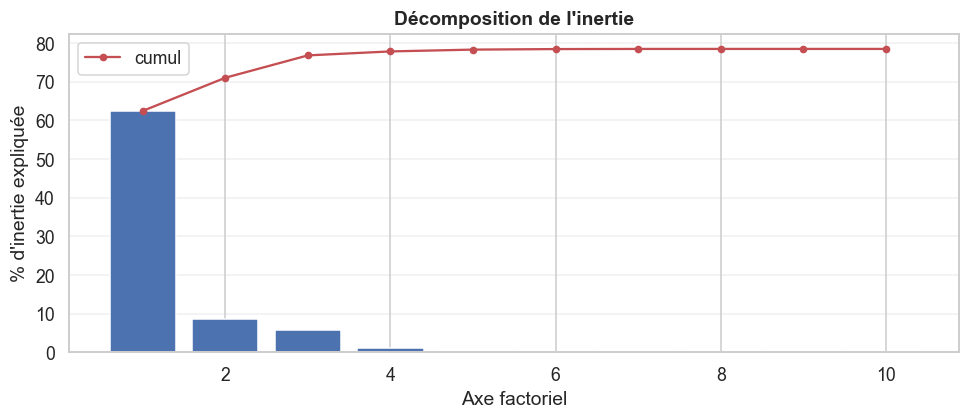

In [ ]:
K = 10
x = np.arange(1, K + 1)
pct_gre = 100 * lam_b / inertie_gre     

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pct_gre[:K], color='#4C72B0')
ax.plot(x, np.cumsum(pct_gre[:K]), color='#C44E52', marker='o', ms=4, label='cumul')
ax.set_xlabel('Axe factoriel'); ax.set_ylabel("% d'inertie expliquée")
ax.set_title("Décomposition de l'inertie", fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()




In [ ]:
# Coordonnées sur tous les axes, nécessaires aux identités vérifiées plus bas
G_all = (V * np.sqrt(lam)) / np.sqrt(c)[:, None]
var_de = VAR_DE          # défini dans la cellule « acm »

# ── 1. Ce que chaque variable apporte, avant toute interprétation
propre = pd.DataFrame({
    'modalités': [D[v].nunique() for v in ACTIVES],
    'inertie propre': [(D[v].nunique() - 1) / Q for v in ACTIVES],
}, index=ACTIVES)
propre['% de l\'inertie totale'] = 100 * propre['inertie propre'] / (J / Q - 1)
display(propre.round(3))

# ── 2. Contribution des variables aux axes
ctr = pd.DataFrame(100 * c[:, None] * G_all[:, :3] ** 2 / lam[:3],
                   index=Z.columns, columns=['axe 1', 'axe 2', 'axe 3'])
par_var = ctr.assign(variable=var_de).groupby('variable')[
    ['axe 1', 'axe 2', 'axe 3']].sum().reindex(ACTIVES)
par_var['attendu si neutre'] = propre['% de l\'inertie totale']
display(par_var.round(1).style.background_gradient(cmap='Blues', axis=None,
                                                   subset=['axe 1', 'axe 2', 'axe 3'])
        .format('{:.1f}'))

f = c * Q
d2 = 1 / f - 1
cos2 = pd.DataFrame(G_all[:, :3] ** 2 / d2[:, None], index=Z.columns,
                    columns=['axe 1', 'axe 2', 'axe 3'])
cos2['3 axes'] = cos2.sum(axis=1)
cos2['part des obs.'] = f
display(pd.concat([cos2.nlargest(6, '3 axes'), cos2.nsmallest(6, '3 axes')]).round(3))




In [ ]:
mod = pd.DataFrame(G[:, :3], index=Z.columns, columns=['axe 1', 'axe 2', 'axe 3'])
mod['masse'] = c
for k in range(3):
    mod[f'contrib {k+1}'] = 100 * c * G[:, k] ** 2 / lam[k]
mod['variable'] = VAR_DE
mod.index = MOD_DE

for k in (1, 2):
    print(f'── Axe {k} : les modalités qui le construisent '
          f'({100*lam_b[k-1]/inertie_gre:.1f} % de l\'inertie ajustée)')
    t = mod.reindex(mod[f'contrib {k}'].sort_values(ascending=False).index)
    print(t[[f'axe {k}', f'contrib {k}', 'variable']].head(8).round(2).to_string())
    print()

# La hauteur suit le nombre de modalités : la figure reste lisible si l'on
# ajoute ou retire une variable active.
fig, axes = plt.subplots(1, 2, figsize=(15, 0.22 * len(mod) + 1.5))
for ax, k in zip(axes, (1, 2)):
    t = mod.sort_values(f'axe {k}')
    coul = ['#C44E52' if v > 0 else '#4C72B0' for v in t[f'axe {k}']]
    ax.barh(range(len(t)), t[f'axe {k}'], color=coul)
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index, fontsize=7.5)
    ax.axvline(0, color='grey', lw=0.8)
    ax.set_xlabel(f'Coordonnée sur l\'axe {k}')
    ax.set_title(f'Axe {k}', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# Plan des modalités actives. Deux modalités proches sont portées par les mêmes
# observations ; une modalité loin de l'origine est rare ou très typée.
PAL = dict(zip(ACTIVES, sns.color_palette('Set1', len(ACTIVES))))

fig, ax = plt.subplots(figsize=(12, 9))
for v in ACTIVES:
    t = mod[mod['variable'] == v]
    ax.scatter(t['axe 1'], t['axe 2'], s=90, color=PAL[v], label=v,
               edgecolors='white', linewidths=1.2, zorder=3)
    # une variable ordonnée dessine une trajectoire : on la relie
    if v in ('co2', 'deriv', 'temp', 'humid', 'moment'):
        ax.plot(t['axe 1'], t['axe 2'], color=PAL[v], lw=1, alpha=0.5, zorder=2)
    for nom, r in t.iterrows():
        ax.annotate(nom, (r['axe 1'], r['axe 2']), fontsize=8.5, fontweight='bold',
                    color=PAL[v], xytext=(6, 4), textcoords='offset points',
                    zorder=4)

ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Axe 1 — {100*lam_b[0]/inertie_gre:.1f} % (Greenacre)')
ax.set_ylabel(f'Axe 2 — {100*lam_b[1]/inertie_gre:.1f} % (Greenacre)')
ax.set_title('Les modalités actives dans le plan factoriel', fontweight='bold')
ax.legend(fontsize=9, loc='best'); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


In [ ]:
def eta2(coord, groupes):
    """Rapport de corrélation : part de la variance des coordonnées expliquée
    par l'appartenance aux modalités. Entre 0 (aucun lien) et 1 (lien parfait)."""
    s = pd.Series(coord)
    g = s.groupby(np.asarray(groupes))
    return (g.count() * (g.mean() - s.mean()) ** 2).sum() / ((s - s.mean()) ** 2).sum()

liens = pd.DataFrame(
    {f'axe {k+1}': [eta2(F[:, k], D[v].values) for v in ACTIVES + ILLUS]
     for k in range(3)},
    index=ACTIVES + ILLUS)
liens['rôle'] = ['active'] * len(ACTIVES) + ['illustrative'] * len(ILLUS)
display(liens.sort_values('axe 1', ascending=False).round(3))

# Rappel : la moyenne des η² sur les seules ACTIVES redonne la valeur propre.
act = liens.loc[ACTIVES]
print('moyenne des η² sur les actives : '
      + ' · '.join(f'{act[f"axe {k+1}"].mean():.4f}' for k in range(3)))
print('valeurs propres                : '
      + ' · '.join(f'{lam[k]:.4f}' for k in range(3)))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    for role, coul, marq, taille in [('active', '#4C72B0', 'o', 130),
                                     ('illustrative', '#C44E52', 'D', 90)]:
        t = liens[liens['rôle'] == role]
        ax.scatter(t[f'axe {i+1}'], t[f'axe {j+1}'], s=taille, color=coul,
                   marker=marq, edgecolors='white', linewidths=1.4, zorder=3,
                   label=role)
        for nom, r in t.iterrows():
            ax.annotate(nom, (r[f'axe {i+1}'], r[f'axe {j+1}']), fontsize=8.5,
                        fontweight='bold', color=coul, xytext=(6, 4),
                        textcoords='offset points', zorder=4)
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
    ax.set_aspect('equal')
    ax.set_xlabel(f'η² avec l\'axe {i+1}')
    ax.set_ylabel(f'η² avec l\'axe {j+1}')
    ax.set_title(f'Carré des liaisons — plan {i+1}·{j+1}', fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()


### Les modalités de non-réponse déforment-elles les axes ?

Un quart des observations n'a pas d'occupation connue : soit la mesure tombe hors
de la semaine couverte par le carnet, soit la position d'un occupant n'a pas été
renseignée. Les coder en modalités explicites permet de ne rien perdre, mais crée
un risque : une modalité lourde peut construire un axe à elle seule et donner une
structure qui ne reflète que le protocole d'enquête.

On le vérifie en refaisant l'ACM sur le seul sous-ensemble complet, puis en
comparant les coordonnées des modalités communes.


In [44]:
def acm_sur(Dx):
    """ACM réduite à l'essentiel, pour comparer deux jeux."""
    Zx = pd.get_dummies(Dx[ACTIVES].astype(str)).astype(np.float64)
    nx, Jx = Zx.shape
    cx = Zx.values.sum(axis=0) / (nx * Q)
    Sx = ((Zx.values / Q - cx) / np.sqrt(cx)) / np.sqrt(nx)
    lx, Vx = np.linalg.eigh(Sx.T @ Sx)
    ox = np.argsort(-lx); lx, Vx = np.clip(lx[ox], 0, None), Vx[:, ox]
    Gx = (Vx[:, :2] * np.sqrt(lx[:2])) / np.sqrt(cx)[:, None]
    return pd.DataFrame(Gx, index=Zx.columns, columns=['axe 1', 'axe 2'])

complet = mod[['axe 1', 'axe 2']].copy()
complet.index = Z.columns
restreint = acm_sur(D[D['occup'].isin(['dans la pièce', 'ailleurs dans le logement',
                                       'absent'])])

comm = [i for i in complet.index.intersection(restreint.index)
        if 'non renseignée' not in i and 'hors semainier' not in i]
print(f'{len(comm)} modalités communes aux deux versions')
# Le sens d'un axe factoriel est arbitraire : une même structure peut ressortir
# avec le signe inverse. C'est la valeur absolue de la corrélation qui compte.
for k in ('axe 1', 'axe 2'):
    r = np.corrcoef(complet.loc[comm, k], restreint.loc[comm, k])[0, 1]
    print(f'  corrélation des coordonnées, {k} : {abs(r):.4f}')

print('\nOù se placent les modalités de non-réponse, et que pèsent-elles ?')
manq = mod[mod.index.str.contains('non renseignée|hors semainier')]
display(manq[['axe 1', 'axe 2', 'contrib 1', 'contrib 2', 'masse']].round(3))
print("Une modalité posée à l'origine et contribuant sous 1 % ne crée pas de "
      "structure : la ligne peut être conservée sans fausser les axes.")

# Les manques sont-ils répartis au hasard dans la journée ? Non — et c'est
# précisément ce qui rendait la vérification ci-dessus nécessaire.
print("\nRépartition horaire des manques (% des observations de chaque heure)")
par_h = pd.crosstab(d_ok['tranche'] // 6, D['occup'], normalize='index') * 100
manquantes = ['hors semainier', 'position non renseignée']
display(par_h[manquantes].loc[[0, 6, 12, 18, 23]].round(1))
for m in manquantes:
    print(f"  {m:<26}varie de {par_h[m].min():.1f} % à {par_h[m].max():.1f} % "
          f"selon l'heure")

# Second contrôle : ces manques correspondent-ils à un état particulier ?
print("\nCO2 médian par modalité d'occupation")
med = d_ok.assign(m=D['occup']).groupby('m')['VALEUR'].median().sort_values()
display(med.round(0).to_frame('CO2 médian'))
print("Les deux modalités de manque se placent entre « ailleurs » et « dans la "
      "pièce » :\nelles se comportent comme un mélange de tous les états, non "
      "comme un état donné.")


22 modalités communes aux deux versions
  corrélation des coordonnées, axe 1 : 0.9983
  corrélation des coordonnées, axe 2 : 0.9502

Où se placent les modalités de non-réponse, et que pèsent-elles ?


,axe 1,axe 2,contrib 1,contrib 2,masse
hors semainier,0.275,0.319,0.554,1.119,0.031
position non renseignée,-0.062,0.099,0.018,0.071,0.021


Une modalité posée à l'origine et contribuant sous 1 % ne crée pas de structure : la ligne peut être conservée sans fausser les axes.

Répartition horaire des manques (% des observations de chaque heure)


occup,hors semainier,position non renseignée
tranche,,
0,20.7,7.4
6,20.7,7.4
12,15.1,11.0
18,10.3,11.9
23,10.1,15.0


  hors semainier            varie de 10.1 % à 20.7 % selon l'heure
  position non renseignée   varie de 7.1 % à 15.0 % selon l'heure

CO2 médian par modalité d'occupation


,CO2 médian
m,
absent,442.0
ailleurs dans le logement,557.0
position non renseignée,653.0
hors semainier,691.0
dans la pièce,904.0


Les deux modalités de manque se placent entre « ailleurs » et « dans la pièce » :
elles se comportent comme un mélange de tous les états, non comme un état donné.


### Vérification de l'axe 2 par une source indépendante

L'axe 2 est porté à 26.3 % par la modalité « chute » de la dérivée, interprétée
comme une aération. Rien ne l'établit jusqu'ici : ce pourrait être un artefact du
lissage, ou une simple sortie des occupants.


Le carnet ne couvre **qu'une journée par occupant**, contre sept pour le semainier.
Après appariement aux mesures, il ne reste que **128 tranches**, soit 0.025 % du jeu.
C'est trop peu pour en faire une modalité d'ACM, où elle serait projetée loin de
l'origine par sa seule rareté. Mais c'est assez pour vérifier une interprétation.


In [45]:
# ── La date du carnet est dans INFOS_BETA, encodé en UTF-16
beta = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_INFOS_BETA.csv',
                   sep=';', encoding='utf-16')
beta['DATE'] = pd.to_datetime(beta['DATE_JOURNALIER'], dayfirst=True, errors='coerce')

carnet = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_JOURNALIER_DATA.csv',
                     sep=';', encoding='latin1')
carnet = carnet[carnet['CODE_HEURE'].str.startswith('V_1')].copy()
carnet['tranche'] = carnet['CODE_HEURE'].str[2:].astype(int) - 1001
carnet = carnet.merge(beta[['CODELIEU', 'NUM_OCCUPANT', 'DATE']],
                      on=['CODELIEU', 'NUM_OCCUPANT'], how='left')

CODE_AERE = 29
aere = carnet[(carnet[['ACTIV_A', 'ACTIV_B', 'ACTIV_C']] == CODE_AERE).any(axis=1)]
evt = aere.groupby(['CODELIEU', 'DATE', 'tranche']).size().rename('n').reset_index()
print(f"« J'AÈRE » déclaré : {len(aere)} tranches · {aere['CODELIEU'].nunique()} logements")

# La classe de dérivée est attachée AVANT la jointure : un merge réinitialise
# l'index, et un realignement après coup mélangerait les lignes.
v = d_ok.assign(classe=D['deriv']).merge(evt, on=['CODELIEU', 'DATE', 'tranche'],
                                         how='left')
v['aere'] = v['n'].notna()
print(f'appariées à une mesure de CO2 : {v["aere"].sum()} '
      f'({100 * v["aere"].mean():.3f} % du jeu)')

from scipy.stats import mannwhitneyu
t = v.groupby('aere')['deriv'].agg(tranches='size', mediane='median', moyenne='mean')
t.index = ['sans déclaration', "« J'AÈRE » déclaré"]
display(t.round(1))

# Répartition dans les classes de dérivée de l'ACM. Ce sont des quintiles, donc
# chaque classe pèse 20 % par construction : tout écart à 20 % est un signal.
rep = pd.crosstab(v['classe'], v['aere'], normalize='columns') * 100
rep.columns = ['sans déclaration', "« J'AÈRE » déclaré"]
display(rep.round(1))


« J'AÈRE » déclaré : 161 tranches · 62 logements
appariées à une mesure de CO2 : 128 (0.025 % du jeu)


,tranches,mediane,moyenne
sans déclaration,514255,-0.8,-1.3
« J'AÈRE » déclaré,128,-117.3,-422.6


,sans déclaration,« J'AÈRE » déclaré
classe,,
chute,20.0,59.4
baisse,20.0,16.4
stable,20.0,10.9
hausse,20.0,9.4
forte hausse,20.0,3.9


In [ ]:
# ── Le dispositif déclaré prédit-il le renouvellement d'air réellement mesuré ?
# Pendant une décroissance sans source, le CO2 suit dC/dt = -n (C - C_ext) : le
# taux de renouvellement n se lit donc directement dans la pente rapportée à
# l'excès de CO2. C'est une mesure physique, indépendante de toute analyse
# factorielle — et c'est le seul juge de paix sur la question du stage.
from scipy.stats import kruskal

C_EXT = 400          # ppm, teneur extérieure de référence
KVNT_L = {1: 'VMC', 2: 'Extracteurs', 3: 'Vent. nat.', 4: 'Aucune vent.'}
kv = d.groupby('CODELIEU')['KVNT'].first().map(KVNT_L)

# On ne retient que les décroissances franches et suffisamment au-dessus de
# l'extérieur : ailleurs le rapport est dominé par le bruit du dénominateur.
dec = d[(d['deriv'] < -20) & (d['VALEUR'] > C_EXT + 200)].copy()
dec['ach'] = -dec['deriv'] / (dec['VALEUR'] - C_EXT)
print(f'{len(dec):,} observations en décroissance nette '
      f'({100 * len(dec) / len(d):.1f} % du jeu)')

# La pièce déclarée vide écarte les décroissances où une source persiste : le
# taux y est moins sous-estimé. Les deux variantes sont données côte à côte.
vide = dec[dec['a_semainier'] & (dec['n_manq'] == 0) & (dec['n_piece'] == 0)]

lignes = []
for nom, x in [('toutes décroissances', dec), ('pièce déclarée vide', vide)]:
    a = x.groupby('CODELIEU')['ach'].median()
    a = a[x.groupby('CODELIEU').size() >= 20]        # au moins 20 points par logement
    if nom == 'toutes décroissances':
        ach_log = a                                  # repris par la cellule suivante
    t = pd.DataFrame({'ach': a, 'ventil': kv}).dropna()
    pv = kruskal(*[g['ach'].values for _, g in t.groupby('ventil')]).pvalue
    lignes.append({'variante': nom, 'logements': len(t),
                   'taux médian (h⁻¹)': a.median(), 'p (Kruskal)': pv,
                   **t.groupby('ventil')['ach'].median().round(3).to_dict()})
res_ach = pd.DataFrame(lignes).set_index('variante')
display(res_ach.round(3))

# ── La même question posée à la mauvaise échelle
# Chaque logement pèse ici plusieurs centaines d'observations : le test croit
# disposer de 100 000 individus indépendants alors qu'il en a 500.
dec_v = dec.assign(ventil=dec['CODELIEU'].map(kv)).dropna(subset=['ventil'])
p_obs = kruskal(*[g['ach'].values for _, g in dec_v.groupby('ventil')]).pvalue
p_log = res_ach.loc['toutes décroissances', 'p (Kruskal)']
print(f'\nMême test, deux unités d\'analyse :')
print(f'   sur {len(dec_v):>7,} observations : p = {p_obs:.2e}   « significatif »')
print(f'   sur {int(res_ach.loc["toutes décroissances", "logements"]):>7,} logements     '
      f': p = {p_log:.3f}   rien du tout')
print('\nLe dispositif déclaré ne prédit pas le renouvellement d\'air mesuré.')
print('Le seul test qui le dit est celui qui compte chaque logement des centaines')
print('de fois : la significativité vient de la pseudo-réplication, pas des données.')


In [ ]:
# ── La ventilation n'est pas un cas isolé : aucune déclaration ne prédit le taux
# On reprend `ach_log` — le taux de renouvellement estimé logement par logement —
# et on le confronte à chaque variable déclarée, au niveau du logement.
from scipy.stats import spearmanr

gl_a = d.groupby('CODELIEU')
DECLA_Q = {'ouverture': "durée d'ouverture des fenêtres", 'KVNT': 'ventilation',
           'FC3': 'type de logement', 'STRMEN': 'structure du ménage',
           'NPP': 'nombre de pièces'}
DECLA_C = {'HSRF': 'surface', 'nb_occ': "nombre d'occupants",
           'VALEUR': 'CO2 médian du logement'}

A = pd.DataFrame({'ach': ach_log})
A['ouverture'] = gl_a['ouverture'].apply(
    lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
for v in ['KVNT', 'FC3', 'STRMEN', 'NPP', 'HSRF', 'nb_occ']:
    A[v] = gl_a[v].first()
A['VALEUR'] = gl_a['VALEUR'].median()
A = A.dropna(subset=['ach'])

lignes = []
for v, lib in DECLA_Q.items():
    t = A.dropna(subset=[v])
    grp = [x['ach'].values for _, x in t.groupby(v) if len(x) > 2]
    lignes.append({'déclaration': lib, 'test': 'Kruskal', 'n': len(t),
                   'p': kruskal(*grp).pvalue,
                   'écart médian max': t.groupby(v)['ach'].median().max()
                                       - t.groupby(v)['ach'].median().min()})
for v, lib in DECLA_C.items():
    t = A.dropna(subset=[v])
    r = spearmanr(t[v], t['ach'])
    lignes.append({'déclaration': lib, 'test': f'Spearman ρ={r.statistic:+.3f}',
                   'n': len(t), 'p': r.pvalue, 'écart médian max': np.nan})
liens_ach = pd.DataFrame(lignes).set_index('déclaration').sort_values('p')
display(liens_ach.style.format({'p': '{:.4f}', 'écart médian max': '{:.3f}'})
        .background_gradient(cmap='Reds_r', subset=['p'], vmin=0, vmax=0.2)
        .set_caption('Le taux de renouvellement mesuré face à chaque déclaration'))

# Le CO2 médian n'est pas une déclaration : c'est le contrôle de cohérence, il
# est exclu du décompte.
CTRL = 'CO2 médian du logement'
seuls = liens_ach.drop(index=CTRL).query('p < 0.05').index.tolist()
print(f"Déclarations liées au taux mesuré à 5 % : "
      f"{', '.join(seuls) if seuls else 'AUCUNE sur les 7 testées'}")
print()
print("Le CO2 médian, lui, est fortement lié au taux : c'est le contrôle de")
print("cohérence physique — moins un logement se renouvelle, plus il est chargé.")
print("Le taux mesure donc bien quelque chose de réel ; c'est le questionnaire qui")
print("ne le prédit pas.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax = axes[0]
o = liens_ach.drop(index='CO2 médian du logement')
ax.barh(range(len(o)), o['p'], color=['#C44E52' if v < .05 else '#4C72B0' for v in o['p']])
ax.axvline(0.05, color='#C44E52', ls='--', lw=1.2)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index, fontsize=9)
ax.set_xlabel('p'); ax.set_title('Aucune déclaration ne passe le seuil de 5 %',
                                 fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
ax.scatter(A['ach'], A['VALEUR'], s=22, alpha=0.5, color='#4C72B0', edgecolors='none')
r = spearmanr(A['ach'], A['VALEUR'])
ax.set_xlabel('taux de renouvellement estimé (h⁻¹)')
ax.set_ylabel('CO2 médian du logement (ppm)')
ax.set_title(f'Contrôle de cohérence : ρ = {r.statistic:+.3f}', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# ── L'objection la plus sérieuse, enfin testable
# On a répété que `KVNT` n'est qu'une case cochée par l'occupant, et qu'elle ne
# dit pas si l'installation fonctionne. `CNL1_Q_PIECE_DATA.csv` contient
# justement le constat de l'ENQUÊTEUR, pièce par pièce :
#   Q51  amenée d'air neuf   1 menuiserie · 2 mur haut · 3 mur bas · 4 bouche
#                            · 5 AUCUNE amenée d'air
#   Q52  état de l'entrée    1 bon · 2 encrassée · 3 masquée par un meuble
#                            · 4 obturée
#   Q53  détalonnage porte   1 < 1 cm · 2 de 1 à 1.9 cm · 3 ≥ 2 cm
# Q53 est la plus pertinente ici : le capteur est dans une chambre, souvent porte
# fermée, et le jeu sous la porte gouverne alors son renouvellement.
from scipy.stats import mannwhitneyu

pie = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_PIECE_DATA.csv',
                  sep=';', encoding='latin1')
capteur = d.groupby('CODELIEU')['IDN_PIECE'].first()
insp = pie.set_index(['CODELIEU', 'IDN_PIECE']).reindex(
    pd.MultiIndex.from_arrays([capteur.index, capteur.values]))
insp.index = capteur.index
print(f'Pièce du capteur retrouvée dans le fichier d\'inspection : '
      f'{insp["Q51"].notna().sum()} / {len(capteur)} logements')

A2 = pd.DataFrame({'ach': ach_log}).join(insp[['Q51', 'Q52', 'Q53']])
# Deux groupes bien dotés valent mieux que cinq modalités dont trois à n < 5.
A2['entrée d\'air'] = np.where(A2['Q51'] == 5, 'aucune amenée d\'air',
                       np.where(A2['Q51'].isin([1, 2, 3, 4]), 'amenée présente', None))
A2['état'] = A2['Q52'].map({'1': 'bon état', '2': 'dégradée', '3': 'dégradée',
                            '4': 'dégradée'})
Q53_L = {1: 'porte < 1 cm', 2: 'porte 1–1.9 cm', 3: 'porte ≥ 2 cm'}
A2['détalonnage'] = A2['Q53'].map(Q53_L)

lignes = []
for col, lib in [('entrée d\'air', "présence d'une amenée d'air neuf"),
                 ('état', "état de l'entrée d'air (inspectée)"),
                 ('détalonnage', 'jeu sous la porte de la chambre')]:
    t = A2.dropna(subset=[col])
    grp = [g['ach'].values for _, g in t.groupby(col) if len(g) > 2]
    pv = (mannwhitneyu(*grp).pvalue if len(grp) == 2
          else kruskal(*grp).pvalue)
    med = t.groupby(col)['ach'].median()
    lignes.append({'constat de l\'enquêteur': lib, 'logements': len(t),
                   'groupes': len(grp), 'écart des médianes': med.max() - med.min(),
                   'p': pv})
    display(t.groupby(col)['ach'].agg(logements='size', médiane='median').round(3)
            .style.set_caption(lib))
insp_res = pd.DataFrame(lignes).set_index('constat de l\'enquêteur')
display(insp_res.style.format({'écart des médianes': '{:.3f}', 'p': '{:.3f}'})
        .background_gradient(cmap='Reds_r', subset=['p'], vmin=0, vmax=0.2))

print()
print("Aucun des trois constats ne prédit le taux mesuré. Le plus frappant est le")
print(f"premier : {int((A2['Q51'] == 5).sum())} des chambres instrumentées n'ont "
      f"AUCUNE amenée d'air neuf,")
print('et leur renouvellement est indiscernable de celui des chambres qui en ont une.')
print()
print("C'est la réponse à l'objection qu'on nous ferait légitimement : le problème")
print("n'est pas que le questionnaire déclarerait mal. Même l'observation directe du")
print('dispositif par un enquêteur ne prédit pas le renouvellement d\'air réel.')


## 4. Une ACP sur les seules valeurs de CO2

L'ACM travaillait sur des modalités. On reprend ici l'analyse sur les **valeurs
brutes**, sans découpage ni indicateur construit.

**L'individu est un logement**, décrit par son **profil journalier moyen** : les
144 valeurs de CO2, une par créneau de dix minutes, moyennées sur ses journées
complètes. Toutes les journées complètes du fichier entrent dans ce calcul —
3 019 journées, soit 434 736 mesures, 85 % du fichier ; la part manquante est celle
des journées partielles, qui n'ont pas leurs 144 créneaux.

**Seul le CO2 est actif.** La dérivée, la température, l'occupation déclarée et les
caractéristiques du logement sont projetées après coup. Les axes ne peuvent donc
rien leur devoir.

**Pourquoi le logement plutôt que la journée.** On pourrait prendre chaque journée
comme individu, ce qui donnerait 3 019 lignes au lieu de 513. Mais un logement en
fournit près de six, et ces journées ne sont pas indépendantes : tout test mené sur
elles compte un logement pour six et rend significatif ce qui ne l'est pas. La
cellule de contrôle en fin de section chiffre l'écart.

Les composantes se lisent comme des **courbes** sur les 24 heures : c'est une ACP
fonctionnelle.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import kruskal

# Journées complètes, puis profil moyen de chaque logement
Jour = d.pivot_table(index=['CODELIEU', 'DATE'], columns='tranche', values='VALEUR')
n_tot = len(Jour)
Jour = Jour.dropna()
Prof = Jour.groupby(level=0).mean()

print(f'{n_tot:,} journées au total, dont {len(Jour):,} complètes '
      f'({144 * len(Jour):,} mesures, {100 * 144 * len(Jour) / len(d):.1f} % du fichier)')
print(f'{Prof.shape[0]} logements ont au moins une journée complète')

# ── Le tableau soumis à l'ACP : un logement par ligne, un créneau par colonne
apercu_p = Prof.copy()
apercu_p.columns = [f'{c // 6:02d}h{(c % 6) * 10:02d}' for c in apercu_p.columns]
print(f"\nLe tableau donné à l'ACP : {apercu_p.shape[0]} logements × "
      f'{apercu_p.shape[1]} créneaux, en ppm')
with pd.option_context('display.max_columns', None, 'display.width', None):
    display(apercu_p.head(8).round(0))
   

Zp = StandardScaler().fit_transform(Prof.values)
acp_p = PCA().fit(Zp)
Cp = acp_p.transform(Zp)
pct_p = 100 * acp_p.explained_variance_ratio_

display(pd.DataFrame({'% inertie': pct_p[:5], '% cumulé': np.cumsum(pct_p[:5])},
                     index=[f'CP{i+1}' for i in range(5)]).round(1))
print(f"Trois composantes portent {pct_p[:3].sum():.1f} % de l'inertie.")


In [ ]:
# ── Cercle des corrélations

charges_p = acp_p.components_.T * np.sqrt(acp_p.explained_variance_)
heures = np.arange(144) / 6

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='#999999', lw=1))
    ax.plot(charges_p[:, i], charges_p[:, j], color='#CCCCCC', lw=1, zorder=1)
    sc = ax.scatter(charges_p[:, i], charges_p[:, j], c=heures, cmap='twilight',
                    s=42, zorder=2, edgecolors='white', linewidths=0.6)
    for h in range(0, 24, 3):                     # un repère toutes les 3 heures
        k = h * 6
        ax.annotate(f'{h}h', (charges_p[k, i], charges_p[k, j]), fontsize=9,
                    fontweight='bold', color='#1A1F2B', zorder=4,
                    xytext=(7, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#999999',
                              alpha=0.85))
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect('equal')
    ax.set_xlabel(f'CP{i+1} — {pct_p[i]:.1f} %')
    ax.set_ylabel(f'CP{j+1} — {pct_p[j]:.1f} %')
    ax.set_title(f'Cercle des corrélations — plan {i+1}·{j+1}', fontweight='bold')
    ax.grid(True, alpha=0.2)
plt.colorbar(sc, ax=axes, label="Heure de la journée", fraction=0.025, pad=0.02)
plt.show()

# Corrélation de chaque plage horaire avec les composantes, et sa qualité de
# représentation dans le plan 1·2.
plages = [('0-6h', 0, 36), ('6-9h', 36, 54), ('9-12h', 54, 72),
          ('12-17h', 72, 102), ('17-21h', 102, 126), ('21-24h', 126, 144)]
tab = pd.DataFrame({f'CP{k+1}': [charges_p[a:b, k].mean() for _, a, b in plages]
                    for k in range(3)}, index=[n for n, _, _ in plages])
tab['cos² plan 1·2'] = [(charges_p[a:b, 0] ** 2 + charges_p[a:b, 1] ** 2).mean()
                        for _, a, b in plages]
# Ce tableau était calculé sans être affiché.
display(tab.round(3).style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1,
                                               subset=['CP1', 'CP2', 'CP3'])
        .set_caption('Corrélation moyenne de chaque plage horaire avec les composantes'))



In [ ]:
# ── Les variables projetées, au niveau du logement
occ_ok = d[d['a_semainier'] & (d['n_manq'] == 0)]
sup_p = d.groupby('CODELIEU').agg(
    deriv_ampl=('deriv', lambda x: x.quantile(.95) - x.quantile(.05)),
    temp_med=('temp', 'median'), humid_med=('humid', 'median'),
    ouverture=('ouverture', lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
    nb_occupants=('nb_occ', 'first'), surface=('HSRF', 'first'),
    nb_pieces=('NPP', 'first'), part_contr=('part_contr', 'first'),
    ventilation=('KVNT', 'first'), type_log=('FC3', 'first')).loc[Prof.index]
sup_p['taux_piece'] = occ_ok.groupby('CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
nuit_p = occ_ok[occ_ok['heure'] < 6].groupby('CODELIEU')['n_piece'].apply(
    lambda x: (x > 0).mean())
jour_p = occ_ok[(occ_ok['heure'] >= 10) & (occ_ok['heure'] < 16)].groupby(
    'CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
sup_p['contraste'] = (nuit_p - jour_p).reindex(Prof.index)

CONT = ['deriv_ampl', 'humid_med', 'ouverture', 'nb_occupants', 'taux_piece',
        'contraste', 'temp_med', 'surface', 'nb_pieces', 'part_contr']

# La ventilation est NOMINALE : une flèche de corrélation n'a pas de sens pour
# elle. Ce qui en a un, c'est la corrélation de chacune de ses INDICATRICES
# (0/1) avec la composante — le coefficient point-bisérial. Chaque modalité
# devient donc sa propre flèche.
KVNT_L = {1: 'VMC', 2: 'Extracteurs', 3: 'Vent. nat.', 4: 'Aucune vent.'}
vent_p = sup_p['ventilation'].map(KVNT_L)
v_ok = vent_p.notna().values
MODS = list(KVNT_L.values())
proj_v = np.array([[np.corrcoef((vent_p[v_ok] == m).astype(float), Cp[v_ok, k])[0, 1]
                    for k in range(3)] for m in MODS])
# Corrélation de chaque variable projetée avec chaque composante : c'est
# exactement ce qui se trace sur le cercle.
proj = np.array([[np.corrcoef(sup_p.loc[sup_p[v].notna(), v],
                              Cp[sup_p[v].notna().values, k])[0, 1]
                  for k in range(3)] for v in CONT])

# ── Le cercle : créneaux actifs en gris, variables projetées en flèches
fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='#999999', lw=1))
    ax.plot(charges_p[:, i], charges_p[:, j], color='#4C72B0', lw=2.5, alpha=0.35,
            zorder=1, label='les 144 créneaux (actifs)')
    for k, v in enumerate(CONT):
        x, y = proj[k, i], proj[k, j]
        ax.arrow(0, 0, x, y, head_width=0.03, color='#C44E52', lw=1.7,
                 length_includes_head=True, zorder=3)
        ax.annotate(v, (x, y), fontsize=8.5, fontweight='bold', color='#8B2F33',
                    ha='left' if x >= 0 else 'right',
                    va='bottom' if y >= 0 else 'top', zorder=4,
                    xytext=(4 if x >= 0 else -4, 3 if y >= 0 else -3),
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none',
                              alpha=0.8))
    # Les quatre modalités de ventilation, à la même échelle que le reste.
    # Elles sont tracées sans étiquette : à cette longueur, un libellé
    # suggérerait une direction que les données ne portent pas.
    for k in range(len(MODS)):
        ax.arrow(0, 0, proj_v[k, i], proj_v[k, j], head_width=0.022,
                 color='#4C72B0', lw=1.4, length_includes_head=True, zorder=2,
                 label='ventilation (4 modalités)' if k == 0 else None)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect('equal')
    ax.set_xlabel(f'CP{i+1} — {pct_p[i]:.1f} %')
    ax.set_ylabel(f'CP{j+1} — {pct_p[j]:.1f} %')
    ax.set_title(f'Variables projetées — plan {i+1}·{j+1}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower left'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

lg = pd.DataFrame(proj_v, index=MODS, columns=['CP1', 'CP2', 'CP3'])
lg['longueur plan 1·2'] = np.hypot(proj_v[:, 0], proj_v[:, 1])
lg['logements'] = [int((vent_p == m).sum()) for m in MODS]
display(lg.round(3).style.format({'CP1': '{:+.3f}', 'CP2': '{:+.3f}',
                                  'CP3': '{:+.3f}', 'longueur plan 1·2': '{:.3f}'})
        .set_caption('Les indicatrices de ventilation sur le cercle'))
print(f"La plus longue flèche de ventilation mesure "
      f"{lg['longueur plan 1·2'].max():.3f} sur un cercle de rayon 1.")
print('Les créneaux de CO2, eux, sont tous au-delà de 0.7. La ventilation est')
print("collée à l'origine : elle ne pointe dans aucune direction du plan.")




In [ ]:
# ── Le traitement correct d'une variable qualitative supplémentaire
# Une nominale ne se projette pas en flèche : elle se projette en BARYCENTRES.
# Chaque modalité est placée au centre de gravité des logements qui la portent.
# La question devient : ces quatre centres sont-ils écartés, ou confondus ?
from scipy.stats import kruskal


def eta2_q(coord, groupes):
    """Part de la variance de la composante expliquée par la modalité."""
    s = pd.Series(coord)
    g = s.groupby(np.asarray(groupes))
    return (g.count() * (g.mean() - s.mean()) ** 2).sum() / ((s - s.mean()) ** 2).sum()


bary = pd.DataFrame(
    {f'CP{k+1}': [Cp[v_ok, k][(vent_p[v_ok] == m).values].mean() for m in MODS]
     for k in range(3)}, index=MODS)
bary['logements'] = [int((vent_p == m).sum()) for m in MODS]

# La référence qui donne sa portée au tableau : l'écart-type des logements
# eux-mêmes sur l'axe. Un barycentre à 1 quand les individus s'étalent sur 10
# n'est pas un déplacement, c'est du bruit.
ref = pd.DataFrame({'étendue des barycentres': [bary[f'CP{k+1}'].max()
                                                - bary[f'CP{k+1}'].min()
                                                for k in range(3)],
                    'écart-type des logements': [Cp[:, k].std() for k in range(3)],
                    'η²': [eta2_q(Cp[v_ok, k], vent_p[v_ok].values) for k in range(3)],
                    'p (Kruskal)': [kruskal(*[Cp[v_ok, k][(vent_p[v_ok] == m).values]
                                              for m in MODS]).pvalue
                                    for k in range(3)]},
                   index=[f'CP{k+1}' for k in range(3)])
ref['étendue / écart-type'] = (ref['étendue des barycentres']
                               / ref['écart-type des logements'])
display(bary.round(2))
display(ref.round(4).style.format({'p (Kruskal)': '{:.3f}', 'η²': '{:.4f}'})
        .set_caption('Les barycentres se déplacent-ils vraiment ?'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
COUL_V = dict(zip(MODS, sns.color_palette('Set2', 4)))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    ax.scatter(Cp[v_ok, i], Cp[v_ok, j], s=16, color='#C9D3D8', edgecolors='none',
               zorder=1, label='les logements')
    for m in MODS:
        sel = (vent_p[v_ok] == m).values
        ax.scatter(Cp[v_ok, i][sel].mean(), Cp[v_ok, j][sel].mean(), s=320,
                   marker='X', color=COUL_V[m], edgecolors='black', linewidths=1.6,
                   zorder=4, label=f'{m}  (n={sel.sum()})')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel(f'CP{i+1} — {pct_p[i]:.1f} %')
    ax.set_ylabel(f'CP{j+1} — {pct_p[j]:.1f} %')
    ax.set_title(f'Barycentres de la ventilation — plan {i+1}·{j+1}',
                 fontweight='bold')
    ax.legend(fontsize=8.5, loc='upper right'); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# Le même plan, recadré sur les seuls barycentres : le zoom qu'il faut pour les
# distinguer dit à lui seul de quelle échelle on parle.
fig, ax = plt.subplots(figsize=(7.5, 6))
for m in MODS:
    sel = (vent_p[v_ok] == m).values
    ax.scatter(Cp[v_ok, 0][sel].mean(), Cp[v_ok, 1][sel].mean(), s=340, marker='X',
               color=COUL_V[m], edgecolors='black', linewidths=1.6, zorder=3)
    ax.annotate(m, (Cp[v_ok, 0][sel].mean(), Cp[v_ok, 1][sel].mean()), fontsize=10,
                fontweight='bold', color=COUL_V[m], xytext=(12, 6),
                textcoords='offset points')
ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel(f'CP1 — {pct_p[0]:.1f} %   (les logements s\'étalent sur ±{Cp[:, 0].std():.0f})')
ax.set_ylabel(f'CP2 — {pct_p[1]:.1f} %   (±{Cp[:, 1].std():.0f})')
ax.set_title('Les mêmes barycentres, zoomés ×3 pour être distinguables',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

e1, p1 = ref.loc['CP1', 'η²'], ref.loc['CP1', 'p (Kruskal)']
p2 = ref.loc['CP2', 'p (Kruskal)']
print(f"CP1 : η² = {e1:.4f}, p = {p1:.3f}. Les barycentres couvrent "
      f"{100 * ref.loc['CP1', 'étendue / écart-type']:.0f} % d'un écart-type.")
print(f"CP2 : p = {p2:.3f} — le seul résultat sous 5 %, mais η² = "
      f"{ref.loc['CP2', 'η²']:.4f} et c'est un test sur trois.")
print('Corrigé du nombre de tests, il ne passe plus. À ne pas présenter comme un effet.')
print()
print('Un détail qui compte pour la lecture : VMC est du côté POSITIF de CP1,')
print('« aucune ventilation » du côté négatif — et CP1 est corrélé +0.94 au CO2')
print("médian. Les logements équipés sont donc du côté chargé, à l'inverse de")
print("l'attendu. Même inversion que dans la CAH : très probablement l'âge du")
print('bâti, la VMC étant obligatoire dans le neuf, plus étanche.')


In [ ]:
# ── Pourquoi le logement et non la journée : le prix de la pseudo-réplication
# Annoncé en tête de section. Le même test est mené deux fois : sur les journées,
# puis sur les logements. Les journées d'un même logement ne sont pas des
# observations indépendantes — il y en a près de six par logement.
Zj = StandardScaler().fit_transform(Jour.values)
Cj = PCA().fit_transform(Zj)
lieu_j = Jour.index.get_level_values(0)
print(f'{len(Jour):,} journées pour {Prof.shape[0]} logements '
      f'({len(Jour) / Prof.shape[0]:.1f} journées par logement)')

lignes = []
for col, lib in [('KVNT', 'ventilation'), ('FC3', 'type de logement'),
                 ('STRMEN', 'structure du ménage'), ('NPP', 'nombre de pièces')]:
    g = d.groupby('CODELIEU')[col].first()
    gj, gl_ = g.reindex(lieu_j), g.reindex(Prof.index)
    pj = kruskal(*[Cj[(gj == m).values, 0] for m in g.dropna().unique()
                   if (gj == m).sum() > 1]).pvalue
    pl = kruskal(*[Cp[(gl_ == m).values, 0] for m in g.dropna().unique()
                   if (gl_ == m).sum() > 1]).pvalue
    lignes.append({'variable': lib, f'p sur {len(Jour):,} journées': pj,
                   f'p sur {Prof.shape[0]} logements': pl,
                   'conclusion': ('significatif deux fois' if pl < .05
                                  else 'significatif à tort' if pj < .05
                                  else 'jamais significatif')})
pseudo = pd.DataFrame(lignes).set_index('variable')
display(pseudo.style.format({pseudo.columns[0]: '{:.2e}',
                             pseudo.columns[1]: '{:.4f}'}))
print("À l'échelle de la journée, tout devient significatif. À l'échelle du")
print("logement — la seule unité indépendante ici — il ne reste presque rien.")
print("C'est pourquoi l'individu de cette ACP est le logement, pas la journée.")


## 5. Une typologie des logements

Les analyses précédentes situent chaque logement dans un plan. Elles ne le rangent
nulle part. On construit ici une **classification ascendante hiérarchique**.

**Ce qu'elle reçoit : les 144 valeurs de CO2, et rien d'autre.** Un logement par
ligne, un créneau de dix minutes par colonne, chaque colonne centrée réduite sur
l'ensemble des logements. Aucune déclaration n'entre dans le calcul des distances.

Ce choix n'est pas allé de soi et la cellule suivante le documente : quatre
entrées possibles y sont comparées. Le résultat décisif est que **les déclarations
seules ne portent aucune partition** — excédent de silhouette de +0.008, soit un
nuage indiscernable d'un nuage sans structure. Les mélanger au CO2 ne l'enrichit
donc pas, cela le dilue.

**Les déclarations servent après coup.** Elles caractérisent les classes au lieu de
les construire, exactement comme les variables illustratives de l'ACM. Le bénéfice
est double : plus aucune pondération arbitraire à défendre, et des valeurs-test qui
valent preuve — une déclaration qui ressort significative n'a pas participé à
fabriquer la classe qu'elle décrit.

Travailler sur le CO2 seul permet en outre de garder les **513 logements** ayant au
moins une journée complète, au lieu des 439 renseignés sur toutes les déclarations.


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

# ── Ce que la CAH reçoit : les 144 créneaux, centrés réduits colonne par colonne
Pc = Prof.copy()
Zc = StandardScaler().fit_transform(Pc.values)
Y = Zc                       # aucune réduction : la CAH voit les 144 dimensions
print(f'Entrée de la CAH : {Y.shape[0]} logements × {Y.shape[1]} créneaux de CO2')
print('Aucune déclaration dans le calcul des distances.')

apercu_c = Pc.copy()
apercu_c.columns = [f'{c // 6:02d}h{(c % 6) * 10:02d}' for c in apercu_c.columns]
with pd.option_context('display.max_columns', 12, 'display.width', None):
    display(apercu_c.iloc[:5, list(range(0, 144, 18))].round(0))

# ── Le tableau de caractérisation : construit ici, utilisé APRÈS la classification
occ_c = d[d['a_semainier'] & (d['n_manq'] == 0)]
gl = d.groupby('CODELIEU')

T = pd.DataFrame(index=Pc.index)
T['co2_median'] = gl['VALEUR'].median()
T['co2_base']   = gl['VALEUR'].quantile(.05)
T['co2_ampl']   = gl['VALEUR'].quantile(.95) - gl['VALEUR'].quantile(.05)
T['deriv_ampl'] = gl['deriv'].apply(lambda x: x.quantile(.95) - x.quantile(.05))
T['temp_med']   = gl['temp'].median()
T['humid_med']  = gl['humid'].median()
T['taux_piece']    = occ_c.groupby('CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
T['taux_logement'] = occ_c.groupby('CODELIEU')['n_log'].apply(lambda x: (x > 0).mean())
nc = occ_c[occ_c['heure'] < 6].groupby('CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
jc = occ_c[(occ_c['heure'] >= 10) & (occ_c['heure'] < 16)].groupby(
    'CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
T['contraste'] = nc - jc
T['surface']      = gl['HSRF'].first()
T['nb_pieces']    = gl['NPP'].first()
T['nb_occupants'] = gl['nb_occ'].first()
T['part_contr']   = gl['part_contr'].first()
T['ouverture']    = gl['ouverture'].apply(
    lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
QUANTI = list(T.columns)
T['ventilation'] = gl['KVNT'].first()
T['type_log']    = gl['FC3'].first()
T['menage']      = gl['STRMEN'].first()
QUALI = ['ventilation', 'type_log', 'menage']
T = T.dropna()
print(f'\nTableau de caractérisation (hors classification) : {len(T)} logements '
      f'sur {len(Pc)}, {len(QUANTI)} quantitatives et {len(QUALI)} qualitatives')


In [ ]:
# ── Que faut-il vraiment donner à la CAH ?
# Quatre entrées possibles, comparées sur les mêmes logements. On mesure, pour
# chacune, si les classes obtenues sont plus nettes qu'un nuage sans structure,
# et si les déclarations les caractérisent après coup.
from scipy.cluster.hierarchy import fcluster
from scipy.stats import chi2_contingency

# `profil_CP*` n'est plus dans T : les composantes sont reprises depuis l'ACP
# de la section 4 pour que la variante A reste testable.
T = T.join(pd.DataFrame(Cp[:, :3], index=Prof.index,
                        columns=['profil_CP1', 'profil_CP2', 'profil_CP3']))
CO2_V = ['profil_CP1', 'profil_CP2', 'profil_CP3', 'co2_median', 'co2_base',
         'co2_ampl', 'deriv_ampl']
DECL_V = [v for v in QUANTI if v not in CO2_V
          and v not in ('temp_med', 'temp_ampl', 'humid_med')]


def prepare(quanti, quali, brut=None, reduire=True):
    """Codage mixte puis, si demandé, ACP à 80 % — la chaîne de la cellule
    précédente. `reduire=False` garde toutes les colonnes : c'est le seul moyen
    de tester vraiment les 144 créneaux, une ACP à 80 % n'en gardant que deux."""
    if brut is not None:
        X = StandardScaler().fit_transform(brut)
    else:
        blocs = [StandardScaler().fit_transform(T[quanti].values)]
        for v in quali:
            Zq = pd.get_dummies(T[v].astype(int).astype(str)).values.astype(float)
            pk = Zq.mean(axis=0)
            blocs.append(((Zq - pk) / np.sqrt(pk)) / np.sqrt(Zq.shape[1] - 1))
        X = np.hstack(blocs)
    if not reduire:
        return X, X
    pct = 100 * PCA().fit(X).explained_variance_ratio_
    return X, PCA().fit_transform(X)[:, :int(np.argmax(np.cumsum(pct) >= 80)) + 1]


ENTREES = {
    'A - CO2 résumé (7 var.)':    prepare(CO2_V, []),
    'B - mixte CO2+déclarations': prepare(QUANTI, QUALI),
    'C - déclarations seules':    prepare(DECL_V, QUALI),
    'D - 144 créneaux, retenu':   prepare(None, None, brut=Prof.loc[T.index].values,
                                          reduire=False),
}

rng = np.random.default_rng(0)
# Les variables de boucle sont suffixées : `X` et `Y` sont les noms utilisés par
# la cellule précédente, et les écraser ferait construire l'arbre de `cah_arbre`
# sur la dernière entrée testée ici au lieu du tableau mixte.
lignes_e, arbres_e = [], {}
for nom, (Xe, Ye) in ENTREES.items():
    arbres_e[nom] = arbre_e = linkage(Ye, method='ward')
    moy_e, cov_e = Ye.mean(axis=0), np.cov(Ye.T)
    ex = {}
    for k in (2, 3, 4):
        dep_e = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Ye)
        lab_e = KMeans(k, init=np.array([Ye[dep_e == j].mean(axis=0) for j in range(k)]),
                       n_init=1, random_state=0).fit_predict(Ye)
        # Référence : un nuage gaussien de même moyenne et même covariance, donc
        # sans aucune classe. L'excédent est ce que la structure ajoute vraiment.
        ref_e = np.mean([silhouette_score(H := rng.multivariate_normal(moy_e, cov_e, len(Ye)),
                                          KMeans(k, n_init=10, random_state=0).fit_predict(H))
                         for _ in range(10)])
        ex[k] = silhouette_score(Ye, lab_e) - ref_e
    # Les déclarations caractérisent-elles la partition à k=3 ?
    l3_e = pd.Series(fcluster(arbre_e, 3, 'maxclust'), index=T.index)
    khi = {v: chi2_contingency(pd.crosstab(l3_e, T[v]).values)[1] for v in QUALI}
    lignes_e.append({'entrée': nom, 'colonnes': Xe.shape[1], 'dim. retenues': Ye.shape[1],
                   'excédent k=2': ex[2], 'k=3': ex[3], 'k=4': ex[4],
                   **{f'p({v})': khi[v] for v in QUALI}})
comp = pd.DataFrame(lignes_e).set_index('entrée')
display(comp.round(3).style.background_gradient(
    cmap='Greens', subset=['excédent k=2', 'k=3', 'k=4'])
    .background_gradient(cmap='Reds_r', subset=[f'p({v})' for v in QUALI])
    .format({'excédent k=2': '{:+.3f}', 'k=3': '{:+.3f}', 'k=4': '{:+.3f}',
             **{f'p({v})': '{:.3f}' for v in QUALI}}))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(len(comp))
ax = axes[0]
for i, k in enumerate(['excédent k=2', 'k=3', 'k=4']):
    ax.bar(x + (i - 1) * 0.26, comp[k], width=0.26, label=k.replace('excédent ', ''))
ax.axhline(0, color='grey', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=18, ha='right', fontsize=8.5)
ax.set_ylabel('silhouette − nuage sans structure')
ax.set_title('Y a-t-il des classes ?', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
for i, v in enumerate(QUALI):
    ax.bar(x + (i - 1) * 0.26, comp[f'p({v})'], width=0.26, label=v)
ax.axhline(0.05, color='#C44E52', ls='--', lw=1.2, label='seuil 5 %')
ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=18, ha='right', fontsize=8.5)
ax.set_ylabel('p du khi² avec la partition k=3')
ax.set_title('Les déclarations caractérisent-elles les classes ?', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Les conclusions sont lues dans le tableau plutôt qu'écrites à la main : elles
# suivent les chiffres si l'entrée change.
pq = [f'p({v})' for v in QUALI]
# B et C contiennent les déclarations : leur khi² est circulaire, la variable a
# servi à bâtir la partition qu'elle est censée caractériser. Seules A et D,
# construites sur le seul CO2, donnent une caractérisation qui vaut preuve.
SANS_DECL = ['A - CO2 résumé (7 var.)', 'D - 144 créneaux, retenu']
nette = comp['excédent k=2'].idxmax()
lie = comp.loc[SANS_DECL, pq].lt(0.05).sum(axis=1).idxmax()

print(f"Structure la plus nette : {nette} ({comp.loc[nette, 'excédent k=2']:+.3f} à k=2)")
print()
print('Parmi les entrées sans déclarations — les seules dont le khi² ne soit pas')
print('circulaire — les classes les mieux caractérisées :')
for e in SANS_DECL:
    marque = '  <<<' if e == lie else ''
    print(f"   {e:<28} "
          + '  '.join(f'{v}={comp.loc[e, f"p({v})"]:.3f}' for v in QUALI) + marque)
print()
c_seul, b_mix = 'C - déclarations seules', 'B - mixte CO2+déclarations'
print(f"Les déclarations seules plafonnent à {comp.loc[c_seul, 'excédent k=2']:+.3f} : "
      'elles ne portent aucune partition.')
print("Les ajouter au CO2 ne l'enrichit pas, cela le dilue — l'entrée B tombe à "
      f"{comp.loc[b_mix, 'excédent k=2']:+.3f}")
print(f"contre {comp.loc[SANS_DECL[0], 'excédent k=2']:+.3f} pour le CO2 résumé seul.")


In [ ]:
arbre_m = linkage(Y, method='ward')
KMAX = 10
sauts_m = pd.DataFrame({'hauteur': [arbre_m[-(k - 1), 2] for k in range(2, KMAX + 1)]},
                       index=range(2, KMAX + 1))
sauts_m['saut'] = sauts_m['hauteur'] - sauts_m['hauteur'].shift(-1)
sauts_m.index.name = 'classes'

# ── Y a-t-il vraiment des groupes ? Comparaison à un nuage sans structure
rng = np.random.default_rng(0)
moy_m, cov_m = Y.mean(axis=0), np.cov(Y.T)
lignes = []
for k in range(2, 8):
    dep = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Y)
    noy = np.array([Y[dep == j].mean(axis=0) for j in range(k)])
    lab = KMeans(n_clusters=k, init=noy, n_init=1, random_state=0).fit_predict(Y)
    ref = [silhouette_score(H := rng.multivariate_normal(moy_m, cov_m, len(Y)),
                            KMeans(k, n_init=10, random_state=0).fit_predict(H))
           for _ in range(15)]
    lignes.append({'k': k, 'silhouette': silhouette_score(Y, lab),
                   'sans structure': np.mean(ref),
                   'excédent': silhouette_score(Y, lab) - np.mean(ref)})
diag = pd.DataFrame(lignes).set_index('k')
display(sauts_m.round(1))
display(diag.round(3))

# ── Dendrogramme complet 
K_VUE = 4
# Le seuil doit passer juste SOUS la (K_VUE-1)e fusion pour que le nombre de
# branches colorees egale K_VUE : au-dessus, cette fusion serait coloree d'un
# seul tenant et l'arbre n'afficherait que K_VUE-1 groupes.
seuil_coul = arbre_m[-(K_VUE - 1), 2] * 0.999

fig, ax = plt.subplots(figsize=(17, 6))
dd = dendrogram(arbre_m, ax=ax, color_threshold=seuil_coul,
                above_threshold_color='#999999', no_labels=True)
ax.set_xlabel(f'Les {len(Pc)} logements, un par feuille')
ax.set_ylabel("Perte d'inertie")
ax.set_title(f'Dendrogramme de Ward — {len(Pc)} logements sur leur seul CO2',
             fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── À quoi correspond chaque feuille
ordre_feuilles = pd.Series(Pc.index[dd['leaves']], name='CODELIEU')

# Chaque branche colorée correspond à une classe : on le vérifie
from scipy.cluster.hierarchy import fcluster
cl_vue = pd.Series(fcluster(arbre_m, K_VUE, criterion='maxclust'), index=Pc.index)
compo = pd.DataFrame({'CODELIEU': ordre_feuilles,
                      'branche': cl_vue.loc[ordre_feuilles].values})
# Cette table était construite sans être affichée : chaque feuille de l'arbre,
# de gauche à droite, avec la branche à laquelle elle appartient.
print(f'\nLes {len(compo)} feuilles, de gauche à droite')
display(compo.head(12))
display(compo['branche'].value_counts().sort_index().rename('logements').to_frame().T)




In [ ]:
# ── Le profil type de chaque branche du dendrogramme
from scipy.cluster.hierarchy import fcluster
FC3_L    = {1: 'Maison', 2: 'Appart.', 3: 'Studio', 4: 'Pièce indép.',
            5: 'Foyer pers. âgées', 6: 'Ferme', 7: 'Chambre hôtel',
            8: 'Constr. provisoire', 9: 'Immeuble prof.'}
KVNT_L   = {1: 'VMC', 2: 'Extracteurs', 3: 'Vent. nat.', 4: 'Aucune vent.'}
STRMEN_L = {1: 'Seul', 2: 'Monoparentale', 3: 'Couple', 4: 'Autre ménage'}
LAB_Q    = {'ventilation': KVNT_L, 'type_log': FC3_L, 'menage': STRMEN_L}

cl = pd.Series(fcluster(arbre_m, K_VUE, criterion='maxclust'), index=Pc.index)
# Renumérotées de gauche à droite du dendrogramme : le numéro correspond alors à
# la position visuelle de la branche dans l'arbre.
ordre = cl.loc[Pc.index[dd['leaves']]].drop_duplicates().tolist()
cl = cl.map({a: i + 1 for i, a in enumerate(ordre)})
COUL_C = sns.color_palette('tab10', K_VUE)
print(' · '.join(f'classe {j+1} : {(cl == j+1).sum()} logements' for j in range(K_VUE)))

# ── Le profil : c'est exactement ce sur quoi la classification a travaillé
heures = np.arange(144) / 6
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
ax = axes[0]
ax.plot(heures, Pc.mean().values, color='black', lw=2, ls='--',
        label='moyenne générale', zorder=5)
for j in range(K_VUE):
    Pj = Pc.loc[cl[cl == j + 1].index]
    ax.plot(heures, Pj.mean().values, color=COUL_C[j], lw=2.4,
            label=f'classe {j+1}  (n={len(Pj)})')
    ax.fill_between(heures, Pj.quantile(.25).values, Pj.quantile(.75).values,
                    color=COUL_C[j], alpha=0.12)
ax.set_xticks(range(0, 25, 3)); ax.set_xlim(0, 24)
ax.set_xlabel('Heure de la journée'); ax.set_ylabel('CO2 (ppm)')
ax.set_title('Journée moyenne de chaque classe   (bande : quartiles)',
             fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
CpT = Cp[Prof.index.get_indexer(Pc.index)]
for j in range(K_VUE):
    m = (cl == j + 1).values
    ax.scatter(CpT[m, 0], CpT[m, 1], s=30, alpha=0.65, color=COUL_C[j],
               edgecolors='none', label=f'classe {j+1}')
    ax.scatter(CpT[m, 0].mean(), CpT[m, 1].mean(), s=240, marker='X',
               color=COUL_C[j], edgecolors='black', linewidths=1.5, zorder=5)
ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'CP1 — {pct_p[0]:.0f} %  (niveau général)')
ax.set_ylabel(f'CP2 — {pct_p[1]:.0f} %  (contraste nuit/jour)')
ax.set_title("Les classes sur le plan de l'ACP   (X = centre)", fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── Repères chiffrés du profil de chaque classe
PLAGES = [('0-6h', 0, 36), ('6-9h', 36, 54), ('9-12h', 54, 72),
          ('12-17h', 72, 102), ('17-21h', 102, 126), ('21-24h', 126, 144)]
rep = pd.DataFrame({n: [Pc.loc[cl[cl == j + 1].index].values[:, a:b].mean()
                        for j in range(K_VUE)] for n, a, b in PLAGES},
                   index=[f'classe {j+1}' for j in range(K_VUE)])
rep['nuit / jour'] = rep['0-6h'] / rep['12-17h']
rep.loc['ENSEMBLE'] = [Pc.values[:, a:b].mean() for _, a, b in PLAGES] + [np.nan]
rep.loc['ENSEMBLE', 'nuit / jour'] = (rep.loc['ENSEMBLE', '0-6h']
                                      / rep.loc['ENSEMBLE', '12-17h'])
display(rep.round(2).style.background_gradient(cmap='YlOrRd', axis=None,
                                               subset=[n for n, _, _ in PLAGES])
        .format('{:.0f}', subset=[n for n, _, _ in PLAGES])
        .format('{:.2f}', subset=['nuit / jour'])
        .set_caption('CO2 moyen par plage horaire (ppm)'))

# ── Les déclarations, qui n'ont PAS servi à construire les classes
# La valeur-test vaut donc ici une preuve, et non une tautologie.
Tc = T.join(cl.rename('classe'), how='inner')
nT = len(Tc)
VT = pd.DataFrame({
    f'classe {j}': (Tc.loc[Tc['classe'] == j, QUANTI].mean() - Tc[QUANTI].mean())
    / (Tc[QUANTI].std(ddof=0)
       * np.sqrt((nT - (Tc['classe'] == j).sum())
                 / ((Tc['classe'] == j).sum() * (nT - 1))))
    for j in sorted(Tc['classe'].unique())})
display(VT.round(1).style.background_gradient(cmap='RdBu_r', vmin=-10, vmax=10,
                                              axis=None).format('{:+.1f}')
        .set_caption(f'Valeur-test des variables NON utilisées · {nT} logements '
                     f'renseignés · |vt| > 2 = significatif'))

from scipy.stats import chi2_contingency
for v in QUALI:
    lib = Tc[v].astype(int).map(LAB_Q[v])
    tab = pd.crosstab(Tc['classe'], lib, normalize='index') * 100
    tab.index = [f'classe {j}' for j in tab.index]
    tab.loc['ENSEMBLE'] = lib.value_counts(normalize=True) * 100
    pv = chi2_contingency(pd.crosstab(Tc['classe'], lib).values)[1]
    display(tab.round(0).style.background_gradient(cmap='Blues', axis=None)
            .format('{:.0f} %').set_caption(f'{v} — khi² p = {pv:.4f}'))

print()
for j in sorted(Tc['classe'].unique()):
    s = VT[f'classe {j}']
    haut = s[s > 2].sort_values(ascending=False).head(4)
    bas = s[s < -2].sort_values().head(4)
    print(f'CLASSE {j} — {(cl == j).sum()} logements, '
          f'nuit {rep.loc[f"classe {j}", "0-6h"]:.0f} ppm / '
          f'jour {rep.loc[f"classe {j}", "12-17h"]:.0f} ppm')
    print('   au-dessus  : ' + (', '.join(f'{k} ({v:+.1f})' for k, v in haut.items())
                                or 'rien'))
    print('   en dessous : ' + (', '.join(f'{k} ({v:+.1f})' for k, v in bas.items())
                                or 'rien'))
k_max, e_max = diag['excédent'].idxmax(), diag['excédent'].max()
print(f"\nL'excédent de silhouette plafonne à {e_max:+.3f} (k={k_max}) : ce découpage")
print(f"en {K_VUE} classes décrit un continuum, il ne révèle pas des types préexistants.")


## 6. Classification de Diday

Les **nuées dynamiques** de Diday généralisent les centres mobiles : chaque classe
est représentée par un **noyau**, et l'algorithme alterne affectation des individus
au noyau le plus proche et recalcul des noyaux. Quand le noyau est le centre de
gravité, on retrouve k-means.

Deux éléments de la méthode sont repris ici et manquent à un k-means ordinaire.

**Les départs multiples.** L'algorithme converge vers un optimum local qui dépend
de l'initialisation. On lance donc vingt départs aléatoires et on retient celui de
moindre inertie intra-classe.

**Les formes fortes.** On croise les vingt partitions obtenues : les individus
toujours regroupés ensemble, quel que soit le départ, forment un noyau stable. Le
nombre de formes fortes et la part d'individus qu'elles couvrent mesurent
directement la **robustesse** de la classification — c'est l'apport propre de
Diday, et cela dit davantage qu'une silhouette.

**Les variables : les 144 valeurs de CO2, et rien d'autre**, comme en section 5.
La distance retenue est euclidienne sur les créneaux centrés réduits ; chaque
logement est comparé aux autres sur sa forme de journée.

La cellule suivante montre pourquoi. Trois équilibrages sont comparés, du CO2 brut
au CO2 mis à parité avec cinq déclarations. Donner du poids aux déclarations coûte
la moitié de la silhouette et fait chuter la reproductibilité entre départs, pour
un gain d'interprétation que la caractérisation *a posteriori* apporte gratuitement.

L'ouverture des fenêtres, le nombre d'occupants, les deux taux de présence et la
surface servent donc à **décrire** les classes, pas à les former.


In [ ]:
# La section ne dépend que de `d` (cellule « data ») et de `Prof` (« acp_jours ») :
# les imports sont repris ici pour qu'elle tourne sans la section 5.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ── Ce que la classification reçoit : les 144 créneaux, et eux seuls
Pd = Prof.copy()
Zco2 = StandardScaler().fit_transform(Pd.values)
print(f'Entrée : {Zco2.shape[0]} logements × {Zco2.shape[1]} créneaux de CO2')

# ── Ce qui servira à DÉCRIRE les classes, une fois qu'elles existeront
occ_d = d[d['a_semainier'] & (d['n_manq'] == 0)]
gd = d.groupby('CODELIEU')
Aut = pd.DataFrame(index=Pd.index)
Aut['ouverture']     = gd['ouverture'].apply(
    lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
Aut['nb_occupants']  = gd['nb_occ'].first()
Aut['taux_piece']    = occ_d.groupby('CODELIEU')['n_piece'].apply(lambda x: (x > 0).mean())
Aut['taux_logement'] = occ_d.groupby('CODELIEU')['n_log'].apply(lambda x: (x > 0).mean())
Aut['surface']       = gd['HSRF'].first()
garde = Aut.dropna().index          # renseignés sur les cinq : caractérisation
print(f'{len(garde)} logements sur {len(Pd)} sont renseignés sur les cinq '
      f'déclarations,\nqui serviront à caractériser les classes sans les construire.')


def diday(X, K, n_dep=20, graine=0):
    """Nuées dynamiques : n_dep départs aléatoires. On retient la partition de
    moindre inertie, et on calcule les formes fortes — les groupes d'individus
    que tous les départs classent ensemble."""
    modeles = [KMeans(K, init='random', n_init=1, random_state=graine + s).fit(X)
               for s in range(n_dep)]
    parts = np.array([m.labels_ for m in modeles])
    best = parts[int(np.argmin([m.inertia_ for m in modeles]))]
    ari = np.mean([adjusted_rand_score(parts[i], parts[j])
                   for i in range(n_dep) for j in range(i + 1, n_dep)])
    cle = pd.Series(['-'.join(map(str, parts[:, i])) for i in range(len(X))])
    return best, ari, pd.factorize(cle)[0]


In [ ]:
# ── Pourquoi le CO2 seul : les trois équilibrages annoncés
# La comparaison se fait sur les logements renseignés sur les cinq déclarations,
# seul sous-ensemble où les trois variantes sont calculables.
Zc_g = StandardScaler().fit_transform(Pd.loc[garde].values)
Za_g = StandardScaler().fit_transform(Aut.loc[garde].values)

PONDS = {'CO2 seul (retenu)': None,
         'CO2 brut + déclarations': 1.0,
         'CO2 à parité avec les 5': np.sqrt(Aut.shape[1]) / np.sqrt(144)}
lignes_p = []
for nom, w in PONDS.items():
    Xp = Zc_g if w is None else np.hstack([Zc_g * w, Za_g])
    part = 100.0 if w is None else 100 * 144 * w ** 2 / (144 * w ** 2 + Aut.shape[1])
    lab, ari, ff = diday(Xp, 3)
    # Écart entre classes sur les déclarations, en écarts-types : mesure ce que
    # la partition « dit » des occupants, quelle que soit la façon dont elle est née.
    ec = pd.DataFrame(Za_g, columns=Aut.columns).assign(cl=lab).groupby('cl').mean()
    lignes_p.append({'équilibrage': nom, 'part du CO2 (%)': part,
                     'silhouette': silhouette_score(Xp, lab),
                     'ARI entre départs': ari, 'formes fortes': len(np.unique(ff)),
                     'écart max des déclarations (σ)': ec.abs().values.max()})
pond = pd.DataFrame(lignes_p).set_index('équilibrage')
display(pond.round(3))

print("Le CO2 brut et le CO2 seul donnent les mêmes chiffres à la troisième")
print("décimale : avec 144 colonnes contre 5, les déclarations ne pèsent déjà plus")
print("rien. Les mettre à parité est le seul moyen de leur donner du poids, et")
print("l'écart entre classes double alors — mais la silhouette tombe de moitié et")
print("la reproductibilité entre départs s'effondre.")
print()
print("On garde donc le CO2 seul, et les déclarations reviennent en caractérisation")
print("où elles produisent des valeurs-test qui, elles, valent preuve.")


In [ ]:
# ── La classification, sur le CO2 seul
Xd = Zco2
K_D = 3
cl_d, ari_d, ff_d = diday(Xd, K_D)

# Les classes sont renumérotées du CO2 le plus bas au plus haut : le numéro
# devient lisible au lieu de dépendre du tirage initial.
niv = pd.Series(Pd.values.mean(axis=1)).groupby(cl_d).mean().sort_values()
cl_d = pd.Series(cl_d).map({a: i for i, a in enumerate(niv.index)}).values

t_ff = pd.Series(ff_d).value_counts()
print(f'K = {K_D} · ARI moyen entre les 20 départs : {ari_d:.3f}')
print(f'{len(t_ff)} formes fortes ; les {K_D} plus grosses couvrent '
      f'{100 * t_ff.head(K_D).sum() / len(Xd):.0f} % des logements')
print(pd.Series(cl_d).value_counts().sort_index()
      .rename('logements').to_frame().T.to_string())

plages_d = [('0-6h', 0, 36), ('6-9h', 36, 54), ('9-12h', 54, 72),
            ('12-17h', 72, 102), ('17-21h', 102, 126), ('21-24h', 126, 144)]
prof_d = pd.DataFrame({n: [Pd.values[cl_d == j, a:b].mean() for j in range(K_D)]
                       for n, a, b in plages_d}, index=range(K_D))
prof_d['nuit / jour'] = prof_d['0-6h'] / prof_d['12-17h']
prof_d.index.name = 'classe'
print('\nCO2 moyen par plage horaire (ppm)')
display(prof_d.round(2).style
        .background_gradient(cmap='YlOrRd', axis=None,
                             subset=[n for n, _, _ in plages_d])
        .format('{:.0f}', subset=[n for n, _, _ in plages_d])
        .format('{:.2f}', subset=['nuit / jour']))

# ── Les cinq déclarations, qui n'ont pas servi à construire les classes
Ad = Aut.loc[garde].join(pd.Series(cl_d, index=Pd.index, name='classe'))
nA = len(Ad)
VT_d = pd.DataFrame({
    f'classe {j}': (Ad.loc[Ad['classe'] == j, Aut.columns].mean()
                    - Ad[Aut.columns].mean())
    / (Ad[Aut.columns].std(ddof=0)
       * np.sqrt((nA - (Ad['classe'] == j).sum())
                 / ((Ad['classe'] == j).sum() * (nA - 1))))
    for j in range(K_D)})
display(VT_d.round(1).style.background_gradient(cmap='RdBu_r', vmin=-6, vmax=6,
                                                axis=None).format('{:+.1f}')
        .set_caption(f'Valeur-test des déclarations · {nA} logements renseignés · '
                     f'|vt| > 2 = significatif'))
print('Médianes brutes')
display(Ad.groupby('classe')[list(Aut.columns)].median().round(2))


In [ ]:
COUL_D = sns.color_palette('Set1', K_D)
heures = np.arange(144) / 6
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Le profil de chaque classe : c'est l'objet même de la classification
ax = axes[0]
ax.plot(heures, Pd.values.mean(axis=0), color='black', lw=1.8, ls='--',
        label='moyenne générale', zorder=5)
for j in range(K_D):
    Pj = Pd.values[cl_d == j]
    ax.plot(heures, Pj.mean(axis=0), color=COUL_D[j], lw=2.4,
            label=f'classe {j}  (n={np.sum(cl_d == j)})')
    ax.fill_between(heures, np.percentile(Pj, 25, axis=0),
                    np.percentile(Pj, 75, axis=0), color=COUL_D[j], alpha=0.12)
ax.set_xticks(range(0, 25, 3)); ax.set_xlim(0, 24)
ax.set_xlabel('Heure'); ax.set_ylabel('CO2 (ppm)')
ax.set_title('Journée type de chaque classe   (bande : quartiles)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Les déclarations, en valeurs-test : elles décrivent, elles n'ont pas construit
ax = axes[1]
x = np.arange(len(Aut.columns))
for j in range(K_D):
    ax.bar(x + (j - (K_D - 1) / 2) * 0.26, VT_d[f'classe {j}'], width=0.26,
           color=COUL_D[j], label=f'classe {j}')
for s in (-2, 2):
    ax.axhline(s, color='#C44E52', ls='--', lw=1.1)
ax.axhline(0, color='grey', lw=0.8)
ax.annotate('seuil |vt| = 2', (len(x) - 0.5, 2.15), fontsize=8, color='#C44E52',
            ha='right', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(Aut.columns, rotation=20, ha='right')
ax.set_ylabel('valeur-test')
ax.set_title('Ce que les déclarations disent des classes', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:

# Les classes portent sur les 513 logements ; les couleurs de variables
# ne s'affichent que là où la déclaration existe.
Cprof = Cp[Prof.index.get_indexer(Pd.index)]
OUV_L = {0: 'fenêtre rarement', 1: 'fenêtre < 30 min', 2: 'fenêtre > 30 min'}

PANNEAUX = [('ouverture', 'RdYlGn'), ('taux_piece', 'RdYlBu'),
            ('taux_logement', 'RdYlBu'), ('nb_occupants', 'viridis'),
            ('surface', 'cividis'), ('co2_median', 'YlOrRd')]
vals = Aut.copy()
vals['co2_median'] = d.groupby('CODELIEU')['VALEUR'].median().loc[Pd.index]

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for ax, (v, cmap) in zip(axes.ravel(), PANNEAUX):
    # Bornes robustes : quelques logements extrêmes écraseraient sinon l'échelle
    lo, hi = vals[v].quantile([0.05, 0.95])
    ok = vals[v].notna().values
    ax.scatter(Cprof[~ok, 0], Cprof[~ok, 1], s=22, color='#D8DEE1',
               edgecolors='none', zorder=1, label='non renseigné')
    sc = ax.scatter(Cprof[ok, 0], Cprof[ok, 1], c=vals[v][ok].clip(lo, hi),
                    cmap=cmap, s=32, alpha=0.85, edgecolors='none', zorder=2)
    cb = plt.colorbar(sc, ax=ax)
    if v == 'ouverture':
        cb.set_ticks([0, 1, 2]); cb.ax.set_yticklabels([OUV_L[k] for k in (0, 1, 2)])
    else:
        cb.set_label(f'{v}  (bornes p05–p95)')
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.axvline(0, color='grey', lw=0.7, ls='--')
    ax.set_xlabel(f'CP1 — {pct_p[0]:.0f} %  (niveau général)')
    ax.set_ylabel(f'CP2 — {pct_p[1]:.0f} %  (contraste nuit/jour)')
    ax.set_title(v.replace('_', ' '), fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle(f'Les {len(Pd)} logements sur le plan factoriel, '
             f'selon chaque variable', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# Quelle variable se répartit vraiment le long des axes ?
corr_v = pd.DataFrame(
    {'CP1': [np.corrcoef(vals[v][vals[v].notna()],
                         Cprof[vals[v].notna().values, 0])[0, 1] for v, _ in PANNEAUX],
     'CP2': [np.corrcoef(vals[v][vals[v].notna()],
                         Cprof[vals[v].notna().values, 1])[0, 1] for v, _ in PANNEAUX]},
    index=[v for v, _ in PANNEAUX])
display(corr_v.round(3).style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)
        .format('{:+.3f}'))


## 7. Ce que tout cela donne en exposition

Les six sections précédentes disent **où se trouve la variance** : dans la journée,
pas entre les logements. Aucune caractéristique déclarée ne prédit ni la position
d'un logement dans les plans factoriels, ni son taux de renouvellement mesuré.

La conséquence pratique est qu'une typologie de logements n'est pas le bon produit.
Ce qui se laisse mesurer, et qui répond à la question sanitaire, ce sont des
**durées passées au-dessus d'un seuil**.

Les seuils retenus ici — 1000, 1500 et 2000 ppm — sont donnés à titre de repères de
lecture et non comme des valeurs réglementaires : le choix appartient aux
encadrants. Le calcul porte sur la nuit, de 0h à 6h, période où le capteur est dans
une chambre occupée et porte souvent fermée.


In [ ]:
# ── Combien de temps passe-t-on au-dessus d'un seuil, la nuit ?
SEUILS = [1000, 1500, 2000]
nuit = d[d['heure'] < 6]

# Deux lectures : la moyenne de la nuit, et le nombre d'heures passées au-dessus.
moy_nuit = nuit.groupby(['CODELIEU', 'DATE'])['VALEUR'].mean()
lignes = []
for s in SEUILS:
    h_nuit = nuit.assign(d=nuit['VALEUR'] > s).groupby(
        ['CODELIEU', 'DATE'])['d'].sum() / 6          # 6 créneaux par heure
    lignes.append({
        'seuil (ppm)': s,
        'nuits en moyenne au-dessus': 100 * (moy_nuit > s).mean(),
        'logements concernés au moins une nuit':
            100 * moy_nuit.gt(s).groupby(level=0).any().mean(),
        'heures/nuit au-dessus (médiane des nuits concernées)':
            h_nuit[h_nuit > 0].median(),
        'part des nuits > 3 h au-dessus': 100 * (h_nuit > 3).mean()})
expo = pd.DataFrame(lignes).set_index('seuil (ppm)')
display(expo.round(1))
print(f'{moy_nuit.groupby(level=0).size().sum():,} nuits · '
      f'{moy_nuit.index.get_level_values(0).nunique()} logements')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
ax.hist(moy_nuit, bins=60, color='#4C72B0', alpha=0.85)
for s, c in zip(SEUILS, ['#DD8452', '#C44E52', '#8B2F33']):
    ax.axvline(s, color=c, ls='--', lw=1.6, label=f'{s} ppm')
ax.set_xlim(300, 3500)
ax.set_xlabel('CO2 moyen de la nuit (0-6h), ppm'); ax.set_ylabel('nuits')
ax.set_title(f'Les {len(moy_nuit):,} nuits du fichier', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# La médiane par logement dit si le dépassement est un accident ou un régime.
ax = axes[1]
med_log = moy_nuit.groupby(level=0).median().sort_values()
ax.plot(np.arange(len(med_log)) / len(med_log) * 100, med_log.values,
        color='#4C72B0', lw=2.2)
for s, c in zip(SEUILS, ['#DD8452', '#C44E52', '#8B2F33']):
    ax.axhline(s, color=c, ls='--', lw=1.4)
    ax.annotate(f'{s} ppm  —  {100 * (med_log > s).mean():.0f} % des logements',
                (2, s), fontsize=8.5, color=c, va='bottom', fontweight='bold')
ax.set_xlabel('logements classés par nuit médiane (%)')
ax.set_ylabel('CO2 médian des nuits, ppm')
ax.set_title('Le dépassement est-il un régime ou un accident ?', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print()
print("Lecture : la courbe de droite est la nuit MÉDIANE de chaque logement. Un")
print("logement au-dessus d'un seuil sur cette courbe y est plus d'une nuit sur deux —")
print("c'est un régime permanent, pas un incident isolé.")


## 8. Du descriptif au prédictif

Les sept sections précédentes ne prédisent rien. Elles décrivent. Mais une
description sérieuse **engage** : elle dit ce qu'un modèle pourra faire, et ce
qu'il ne pourra pas. Cette section vérifie que les engagements sont tenus, en
reprenant la cible du notebook `detection_occupation.ipynb` — *l'occupant est-il
dans la pièce du capteur ?*

Quatre énoncés issus des analyses ci-dessus, chacun réfutable.

| # | Ce que le descriptif affirme | Ce qui doit s'ensuivre |
|---|---|---|
| 1 | η²(CODELIEU, axe 1) = 0.124 : **88 % de l'axe 1 est intra-logement** | Normaliser le CO2 logement par logement doit améliorer la détection |
| 2 | L'occupation contribue 29.6 % à l'axe 1, le CO2 médian passe de 442 à 904 ppm | Le CO2 seul doit déjà séparer la présence, sans modèle |
| 3 | Aucune déclaration : η² < 0.03, tous les p > 0.05 | Ajouter le questionnaire aux variables du modèle ne doit rien apporter |
| 4 | CP2 de l'ACP fonctionnelle = contraste nuit/jour | Le modèle doit mieux marcher là où ce contraste est marqué |

Le quatrième est le plus exigeant : il demande qu'un axe construit **sans jamais
voir les étiquettes d'occupation** prédise où un modèle supervisé réussira.


In [ ]:
# ── Énoncés 1 à 3 : le signal, la normalisation, les déclarations
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier

# La cible n'existe que là où le semainier est complet : c'est le sous-ensemble
# sur lequel une occupation déclarée est connue sans ambiguïté.
occ_p = d['a_semainier'] & (d['n_manq'] == 0)
P = d[occ_p].copy()
P['y'] = (P['n_piece'] > 0).astype(int)

# Normalisation par logement : chaque logement devient sa propre référence.
# C'est exactement ce que l'énoncé 1 recommande.
gp = P.groupby('CODELIEU')['VALEUR']
P['co2_z'] = (P['VALEUR'] - gp.transform('mean')) / gp.transform('std')
P['h_sin'] = np.sin(2 * np.pi * P['heure'] / 24)
P['h_cos'] = np.cos(2 * np.pi * P['heure'] / 24)
print(f'{len(P):,} observations · {P["CODELIEU"].nunique()} logements · '
      f'{100 * P["y"].mean():.1f} % de présence déclarée')

# ── Énoncés 1 et 2 : aucune modélisation, une variable, une AUC
seule = pd.DataFrame({'AUC': [
    roc_auc_score(P['y'], P[v]) for v in ['VALEUR', 'co2_z', 'deriv']]},
    index=['CO2 brut', 'CO2 normalisé par logement', 'dérivée du CO2'])
display(seule.round(3).style.set_caption(
    'Une seule variable, aucun modèle : sépare-t-elle la présence ?'))
gain = seule.loc['CO2 normalisé par logement', 'AUC'] - seule.loc['CO2 brut', 'AUC']
print(f'Énoncé 1 — la normalisation par logement gagne {gain:+.3f} d\'AUC.')
print(f'Énoncé 2 — le CO2 brut atteint déjà '
      f'{seule.loc["CO2 brut", "AUC"]:.3f} sans aucun apprentissage.')

# ── Énoncé 3 : ablation, découpe par logement pour ne pas se mentir
y_p, grp_p = P['y'].values, P['CODELIEU'].values
i_tr, i_te = next(GroupShuffleSplit(1, test_size=.3, random_state=0)
                  .split(P, y_p, groups=grp_p))
DECLAS = ['KVNT', 'FC3', 'STRMEN', 'HSRF', 'NPP', 'nb_occ', 'ouverture', 'part_contr']
BLOCS = {
    'CO2 normalisé seul': ['co2_z'],
    '+ heure':            ['co2_z', 'h_sin', 'h_cos'],
    '+ dérivée':          ['co2_z', 'h_sin', 'h_cos', 'deriv'],
    '+ déclarations':     ['co2_z', 'h_sin', 'h_cos', 'deriv'] + DECLAS,
}
lignes = []
for nom, f in BLOCS.items():
    Xb = P[f].values
    mdl = HistGradientBoostingClassifier(random_state=0).fit(Xb[i_tr], y_p[i_tr])
    lignes.append({'variables du modèle': nom, 'nombre': len(f),
                   'AUC': roc_auc_score(y_p[i_te], mdl.predict_proba(Xb[i_te])[:, 1])})
abl = pd.DataFrame(lignes).set_index('variables du modèle')
abl['gain'] = abl['AUC'].diff()
display(abl.round(4).style.format({'AUC': '{:.4f}', 'gain': '{:+.4f}'})
        .set_caption(f'Ablation · découpe par logement · '
                     f'{P.iloc[i_te]["CODELIEU"].nunique()} logements de test'))
print(f'Énoncé 3 — les 8 déclarations apportent {abl["gain"].iloc[-1]:+.4f} d\'AUC.')

# ── Et la pseudo-réplication, dans un cadre prédictif ?
X4 = P[BLOCS['+ dérivée']].values
rng_p = np.random.default_rng(0)
ia = rng_p.permutation(len(P)); n_tr = int(.7 * len(P))
auc_alea = roc_auc_score(y_p[ia[n_tr:]], HistGradientBoostingClassifier(random_state=0)
                         .fit(X4[ia[:n_tr]], y_p[ia[:n_tr]])
                         .predict_proba(X4[ia[n_tr:]])[:, 1])
auc_grp = abl.loc['+ dérivée', 'AUC']
print()
print(f'Découpe aléatoire    : AUC = {auc_alea:.3f}')
print(f'Découpe par logement : AUC = {auc_grp:.3f}   écart {auc_alea - auc_grp:+.3f}')
print('La pseudo-réplication gonflait les p-values d\'un facteur énorme (section 4) ;')
print('sur une AUC elle ne change presque rien. Les deux ne mesurent pas la même')
print('chose : un test demande si un écart existe, une AUC demande de quelle taille.')
print('La découpe par logement reste indispensable — non pour le chiffre, mais pour')
print('pouvoir dire que le modèle marchera sur un logement jamais vu.')


In [ ]:
# ── Énoncé 4 : un axe non supervisé annonce-t-il où le modèle réussira ?
# On calcule une AUC par logement de test, puis on la confronte à la position du
# logement sur le plan de l'ACP de la section 4 — un plan construit sur les seuls
# profils de CO2, sans que l'occupation y soit jamais entrée.
from scipy.stats import spearmanr

mdl_p = HistGradientBoostingClassifier(random_state=0).fit(X4[i_tr], y_p[i_tr])
te = P.iloc[i_te].assign(proba=mdl_p.predict_proba(X4[i_te])[:, 1])
auc_log = (te.groupby('CODELIEU')
           .apply(lambda x: roc_auc_score(x['y'], x['proba'])
                  if x['y'].nunique() > 1 else np.nan).dropna().rename('AUC'))
print(f'{len(auc_log)} logements de test · AUC médiane {auc_log.median():.3f} · '
      f'quartiles {auc_log.quantile(.25):.3f} – {auc_log.quantile(.75):.3f}')

pos = pd.DataFrame(Cp[:, :2], index=Prof.index, columns=['CP1', 'CP2'])
# Un indicateur naïf, pour vérifier que l'axe apporte plus qu'une amplitude brute
gq = d.groupby('CODELIEU')['VALEUR']
pos['amplitude'] = gq.quantile(.95) - gq.quantile(.05)
lien = pos.join(auc_log, how='inner')

t = pd.DataFrame({n: {'ρ de Spearman': (r := spearmanr(lien[n], lien['AUC'])).statistic,
                      'p': r.pvalue}
                  for n in ['CP1', 'CP2', 'amplitude']}).T
display(t.style.format({'ρ de Spearman': '{:+.3f}', 'p': '{:.4f}'})
        .set_caption("Où le modèle réussit, face à la position dans le plan factoriel"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
sc = ax.scatter(lien['CP1'], lien['CP2'], c=lien['AUC'], cmap='RdYlGn',
                vmin=lien['AUC'].quantile(.05), vmax=1, s=48, edgecolors='white',
                linewidths=0.6)
plt.colorbar(sc, ax=ax, label='AUC du modèle dans ce logement')
ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'CP1 — {pct_p[0]:.0f} %  (niveau général)')
ax.set_ylabel(f'CP2 — {pct_p[1]:.0f} %  (contraste nuit/jour)')
ax.set_title('Les logements de test sur le plan de la section 4', fontweight='bold')
ax.grid(True, alpha=0.25)

ax = axes[1]
q = pd.qcut(lien['CP2'], 4, labels=['CP2 Q1', 'Q2', 'Q3', 'Q4'])
bp = ax.boxplot([lien.loc[q == c, 'AUC'].values for c in q.cat.categories],
                labels=list(q.cat.categories), patch_artist=True, widths=.6)
for b, c in zip(bp['boxes'], sns.color_palette('RdYlGn', 4)):
    b.set_facecolor(c); b.set_alpha(.75)
for med in bp['medians']:
    med.set_color('#1A1F2B'); med.set_linewidth(1.6)
ax.set_ylabel('AUC par logement')
ax.set_xlabel('Quartile de contraste nuit/jour (CP2)')
ax.set_title('Le contraste nuit/jour annonce la détectabilité', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

r2 = spearmanr(lien['CP2'], lien['AUC'])
print(f"Énoncé 4 — ρ(AUC, CP2) = {r2.statistic:+.3f}, p = {r2.pvalue:.1e}.")
print(f"   quartile bas  : AUC médiane {lien.loc[q == 'CP2 Q1', 'AUC'].median():.3f}")
print(f"   quartile haut : AUC médiane {lien.loc[q == 'Q4', 'AUC'].median():.3f}")
print()
print("L'amplitude brute du CO2, elle, ne dit rien (voir le tableau). Ce n'est donc")
print("pas la taille du signal qui rend l'occupation détectable, c'est sa FORME —")
print("et c'est précisément ce que l'axe factoriel isole et qu'un indicateur")
print("élémentaire manque. L'analyse descriptive gagne ici son utilité : elle")
print("désigne à l'avance les logements où la détection sera fragile.")
